In [30]:
# =====================================================
# CELL 1 — Import libraries
# =====================================================

# data manipulation
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# file handling
import os
from glob import glob

# ML preprocessing
from sklearn.preprocessing import StandardScaler

# models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ignore warnings
import warnings
warnings.filterwarnings("ignore")

print("Libraries loaded")

Libraries loaded


In [31]:
# =====================================================
# CELL 2 — Load dataset
# =====================================================

data_path = "/kaggle/input/datasets/borismarjanovic/price-volume-data-for-all-us-stocks-etfs/Data/Stocks"

files = glob(data_path + "/*.txt")

print("Total files:", len(files))


def load_file(file):

    try:
        df = pd.read_csv(file)

        ticker = os.path.basename(file).replace(".us.txt", "")

        df["ticker"] = ticker

        return df

    except:
        return None


data_list = []

for file in files[:400]:   # using 400 stocks for speed
    df = load_file(file)

    if df is not None:
        data_list.append(df)


stock_data = pd.concat(data_list, ignore_index=True)

print("Dataset shape:", stock_data.shape)

stock_data.head()

Total files: 7195
Dataset shape: (749348, 8)


,Date,Open,High,Low,Close,Volume,OpenInt,ticker
0,2005-02-25,12.09,13.20,12.06,13.08,318399,0,ufi
1,2005-02-28,13.05,13.32,12.27,12.57,33966,0,ufi
2,2005-03-01,12.60,12.78,12.09,12.66,42066,0,ufi
3,2005-03-02,12.90,13.62,12.75,13.50,81666,0,ufi
4,2005-03-03,13.65,13.65,12.60,12.78,100299,0,ufi


In [32]:
# =====================================================
# CELL 3 — Data cleaning
# =====================================================

stock_data["Date"] = pd.to_datetime(stock_data["Date"])

stock_data = stock_data.sort_values(["ticker","Date"])

stock_data = stock_data.drop_duplicates()

stock_data = stock_data.reset_index(drop=True)

print(stock_data.shape)

(749348, 8)


In [33]:
# =====================================================
# CELL 4 ? Feature engineering
# =====================================================

# returns
stock_data["return_1d"] = stock_data.groupby("ticker")["Close"].pct_change()

stock_data["log_return"] = np.log(
    stock_data["Close"] /
    stock_data.groupby("ticker")["Close"].shift(1)
)

# spreads
stock_data["high_low_range"] = (
    stock_data["High"] - stock_data["Low"]
) / stock_data["Close"]

stock_data["open_close_change"] = (
    stock_data["Close"] - stock_data["Open"]
) / stock_data["Open"]

# volume signal
stock_data["volume_change"] = stock_data.groupby("ticker")["Volume"].pct_change()

# moving averages
for window in [5,10,20,50,100,200]:

    stock_data[f"sma_{window}"] = (
        stock_data.groupby("ticker")["Close"]
        .transform(lambda x: x.rolling(window).mean())
    )

# trend-strength features expected later in the notebook
# These are derived only from same-day and historical moving averages,
# so they stay leakage-free.
stock_data["trend_strength_20_50"] = (
    stock_data["sma_20"] / (stock_data["sma_50"] + 1e-9)
) - 1

stock_data["trend_strength_50_200"] = (
    stock_data["sma_50"] / (stock_data["sma_200"] + 1e-9)
) - 1

# MA slopes as one-day percentage changes of the moving averages
stock_data["sma_20_slope"] = (
    stock_data.groupby("ticker")["sma_20"].pct_change()
)

stock_data["sma_50_slope"] = (
    stock_data.groupby("ticker")["sma_50"].pct_change()
)

# volatility
for window in [5,10,20,50]:

    stock_data[f"volatility_{window}"] = (
        stock_data.groupby("ticker")["return_1d"]
        .transform(lambda x: x.rolling(window).std())
    )

# momentum
stock_data["momentum_3"] = stock_data.groupby("ticker")["Close"].pct_change(3)

stock_data["momentum_7"] = stock_data.groupby("ticker")["Close"].pct_change(7)

stock_data["momentum_14"] = stock_data.groupby("ticker")["Close"].pct_change(14)

stock_data["momentum_acceleration"] = (
    stock_data["momentum_7"] -
    stock_data["momentum_3"]
)

stock_data.head()


,Date,Open,High,Low,Close,Volume,OpenInt,ticker,return_1d,log_return,...,sma_20_slope,sma_50_slope,volatility_5,volatility_10,volatility_20,volatility_50,momentum_3,momentum_7,momentum_14,momentum_acceleration
0,2005-02-25,4.4844,4.5556,4.4765,4.5082,319324,0,abb,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2005-02-28,4.5873,4.5873,4.4685,4.5082,534773,0,abb,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2005-03-01,4.5479,4.5873,4.5399,4.5717,409945,0,abb,0.014085,0.013987,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2005-03-02,4.5717,4.5954,4.5399,4.5636,239933,0,abb,-0.001772,-0.001773,...,NaN,NaN,NaN,NaN,NaN,NaN,0.012289,NaN,NaN,NaN
4,2005-03-03,4.6112,4.6666,4.5873,4.6270,962639,0,abb,0.013893,0.013797,...,NaN,NaN,NaN,NaN,NaN,NaN,0.026352,NaN,NaN,NaN


In [34]:
# =====================================================
# CELL 5 — Create labels
# =====================================================

# trend label
stock_data["trend_label"] = 1

stock_data.loc[
    stock_data["sma_20"] > stock_data["sma_50"],
    "trend_label"
] = 2

stock_data.loc[
    stock_data["sma_20"] < stock_data["sma_50"],
    "trend_label"
] = 0


# risk label
low_thr = stock_data["volatility_20"].quantile(0.33)
high_thr = stock_data["volatility_20"].quantile(0.66)

stock_data["risk_label"] = 1

stock_data.loc[
    stock_data["volatility_20"] < low_thr,
    "risk_label"
] = 0

stock_data.loc[
    stock_data["volatility_20"] > high_thr,
    "risk_label"
] = 2


# direction label
stock_data["future_return_5d"] = (
    stock_data.groupby("ticker")["Close"]
    .shift(-5) / stock_data["Close"] - 1
)

stock_data["direction_label"] = np.nan

stock_data.loc[
    stock_data["future_return_5d"] > 0.02,
    "direction_label"
] = 1

stock_data.loc[
    stock_data["future_return_5d"] < -0.02,
    "direction_label"
] = 0

stock_data.head()

,Date,Open,High,Low,Close,Volume,OpenInt,ticker,return_1d,log_return,...,volatility_20,volatility_50,momentum_3,momentum_7,momentum_14,momentum_acceleration,trend_label,risk_label,future_return_5d,direction_label
0,2005-02-25,4.4844,4.5556,4.4765,4.5082,319324,0,abb,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1,1,0.047425,1.0
1,2005-02-28,4.5873,4.5873,4.4685,4.5082,534773,0,abb,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,1,1,0.035136,1.0
2,2005-03-01,4.5479,4.5873,4.5399,4.5717,409945,0,abb,0.014085,0.013987,...,NaN,NaN,NaN,NaN,NaN,NaN,1,1,0.027714,1.0
3,2005-03-02,4.5717,4.5954,4.5399,4.5636,239933,0,abb,-0.001772,-0.001773,...,NaN,NaN,0.012289,NaN,NaN,NaN,1,1,0.015646,NaN
4,2005-03-03,4.6112,4.6666,4.5873,4.6270,962639,0,abb,0.013893,0.013797,...,NaN,NaN,0.026352,NaN,NaN,NaN,1,1,0.017139,NaN


In [35]:
# =====================================================
# CELL 6 — final ML dataset
# =====================================================

stock_data = stock_data.replace([np.inf,-np.inf],np.nan)

stock_data = stock_data.dropna()

features = [

    "return_1d",
    "log_return",
    "high_low_range",
    "open_close_change",
    "volume_change",

    "sma_5",
    "sma_10",
    "sma_100",
    "sma_200",

    "volatility_5",
    "volatility_10",
    "volatility_20",
    "volatility_50",

    "momentum_3",
    "momentum_7",
    "momentum_14",
    "momentum_acceleration"
]

X = stock_data[features]

y_trend = stock_data["trend_label"]

y_risk = stock_data["risk_label"]

y_direction = stock_data["direction_label"]

print(X.shape)

(385346, 17)


In [36]:
# =====================================================
# CELL 7 — time split
# =====================================================

stock_data = stock_data.sort_values("Date")

split = int(len(stock_data)*0.8)

train = stock_data.iloc[:split]
test = stock_data.iloc[split:]

X_train = train[features]
X_test = test[features]

y_train_trend = train["trend_label"]
y_test_trend = test["trend_label"]

y_train_risk = train["risk_label"]
y_test_risk = test["risk_label"]

y_train_direction = train["direction_label"]
y_test_direction = test["direction_label"]

print(X_train.shape)

(308276, 17)


In [37]:
# =====================================================
# CELL 8 — scaling
# =====================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [38]:
# =====================================================
# CELL 9 ? train models
# =====================================================

from sklearn.base import clone


def build_xgb_for_task(task_name):
    # Fresh XGBoost instance per task avoids parameter carry-over across
    # binary and multi-class fits on newer Kaggle/XGBoost versions.
    common_params = {
        "n_estimators": 300,
        "max_depth": 5,
        "learning_rate": 0.05,
        "random_state": 42,
        "n_jobs": -1,
    }

    if task_name in {"trend", "risk"}:
        return XGBClassifier(
            objective="multi:softprob",
            num_class=3,
            **common_params,
        )

    return XGBClassifier(
        objective="binary:logistic",
        **common_params,
    )


base_models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        random_state=42,
        n_jobs=-1,
    ),
}

results = []

for name, base_model in base_models.items():
    model = clone(base_model)
    model.fit(X_train, y_train_trend)
    trend_acc = accuracy_score(y_test_trend, model.predict(X_test))

    model = clone(base_model)
    model.fit(X_train, y_train_risk)
    risk_acc = accuracy_score(y_test_risk, model.predict(X_test))

    model = clone(base_model)
    model.fit(X_train, y_train_direction)
    direction_acc = accuracy_score(y_test_direction, model.predict(X_test))

    results.append([name, trend_acc, risk_acc, direction_acc])

xgb_trend_benchmark = build_xgb_for_task("trend")
xgb_trend_benchmark.fit(X_train, y_train_trend)
trend_acc = accuracy_score(y_test_trend, xgb_trend_benchmark.predict(X_test))

xgb_risk_benchmark = build_xgb_for_task("risk")
xgb_risk_benchmark.fit(X_train, y_train_risk)
risk_acc = accuracy_score(y_test_risk, xgb_risk_benchmark.predict(X_test))

xgb_direction_benchmark = build_xgb_for_task("direction")
xgb_direction_benchmark.fit(X_train, y_train_direction)
direction_acc = accuracy_score(y_test_direction, xgb_direction_benchmark.predict(X_test))

results.append(["XGBoost", trend_acc, risk_acc, direction_acc])

results_df = pd.DataFrame(
    results,
    columns=["Model", "Trend", "Risk", "Direction"]
)

results_df


,Model,Trend,Risk,Direction
0,Logistic,0.792617,0.987570,0.526521
1,RandomForest,0.743934,1.000000,0.528260
2,XGBoost,0.801920,0.996276,0.527443


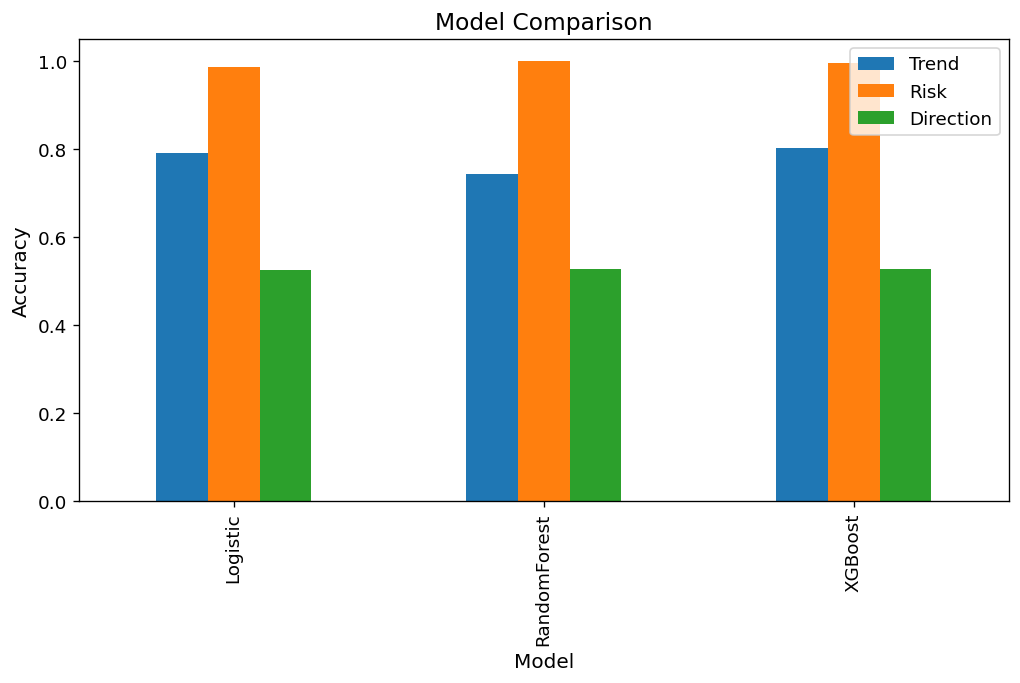

In [39]:
# =====================================================
# CELL 10 — comparison plot
# =====================================================

results_df.set_index("Model").plot(

    kind="bar",
    figsize=(10,5)

)

plt.title("Model Comparison")

plt.ylabel("Accuracy")

plt.show()

In [40]:
# ================================
# STEP 11: Risk label
# ================================

# compute volatility thresholds
low_threshold = stock_data["volatility_20"].quantile(0.33)
high_threshold = stock_data["volatility_20"].quantile(0.66)

# default medium risk
stock_data["risk_label"] = 1


# low risk
stock_data.loc[
    stock_data["volatility_20"] < low_threshold,
    "risk_label"
] = 0


# high risk
stock_data.loc[
    stock_data["volatility_20"] > high_threshold,
    "risk_label"
] = 2


print("Risk labels created")

print("\nThresholds used:")
print("Low risk <", low_threshold)
print("High risk >", high_threshold)

print("\nRisk distribution:")
print(stock_data["risk_label"].value_counts())

display(
    stock_data[
        [
            "Date",
            "ticker",
            "volatility_20",
            "risk_label"
        ]
    ].head(20)
)

Risk labels created

Thresholds used:
Low risk < 0.018572449463970252
High risk > 0.03122413472430369

Risk distribution:
risk_label
2    131018
0    127164
1    127164
Name: count, dtype: int64


,Date,ticker,volatility_20,risk_label
17975,1984-01-03,amd,0.016895,0
17977,1984-01-05,amd,0.018985,1
17979,1984-01-09,amd,0.016707,0
17980,1984-01-10,amd,0.017577,0
17983,1984-01-13,amd,0.018251,0
17984,1984-01-16,amd,0.018293,0
17985,1984-01-17,amd,0.018141,0
17986,1984-01-18,amd,0.019699,1
17987,1984-01-19,amd,0.019648,1
17988,1984-01-20,amd,0.020000,1


In [41]:
# ================================
# STEP 12: Anomaly label
# ================================

# compute z-score of returns
stock_data["return_zscore"] = (
    stock_data.groupby("ticker")["return_1d"]
    .transform(lambda x: (x - x.mean()) / x.std())
)

# default normal
stock_data["anomaly_label"] = 0

# anomaly condition
stock_data.loc[
    abs(stock_data["return_zscore"]) > 3,
    "anomaly_label"
] = 1


print("Anomaly labels created")

print("\nAnomaly distribution:")
print(stock_data["anomaly_label"].value_counts())

display(
    stock_data[
        [
            "Date",
            "ticker",
            "return_1d",
            "return_zscore",
            "anomaly_label"
        ]
    ].head(20)
)

Anomaly labels created

Anomaly distribution:
anomaly_label
0    379249
1      6097
Name: count, dtype: int64


,Date,ticker,return_1d,return_zscore,anomaly_label
17975,1984-01-03,amd,0.003567,0.074258,0
17977,1984-01-05,amd,0.010245,0.245609,0
17979,1984-01-09,amd,0.021111,0.524449,0
17980,1984-01-10,amd,-0.023939,-0.631575,0
17983,1984-01-13,amd,-0.020675,-0.547807,0
17984,1984-01-16,amd,0.000000,-0.017279,0
17985,1984-01-17,amd,0.021111,0.524449,0
17986,1984-01-18,amd,-0.027203,-0.715342,0
17987,1984-01-19,amd,0.013423,0.327161,0
17988,1984-01-20,amd,-0.027594,-0.725359,0


In [42]:
# ================================
# STEP 13: Buy/Sell label
# ================================

# future 5-day return
stock_data["future_return_5d"] = (
    stock_data.groupby("ticker")["Close"]
    .shift(-5) / stock_data["Close"] - 1
)

# initialize hold
stock_data["direction_label"] = np.nan


# BUY condition
stock_data.loc[
    stock_data["future_return_5d"] > 0.02,
    "direction_label"
] = 1


# SELL condition
stock_data.loc[
    stock_data["future_return_5d"] < -0.02,
    "direction_label"
] = 0


print("Buy/Sell labels created")

print("\nDistribution:")
print(stock_data["direction_label"].value_counts(dropna=True))

display(
    stock_data[
        [
            "Date",
            "ticker",
            "Close",
            "future_return_5d",
            "direction_label"
        ]
    ].head(20)
)

Buy/Sell labels created

Distribution:
direction_label
1.0    168252
0.0    156837
Name: count, dtype: int64


,Date,ticker,Close,future_return_5d,direction_label
17975,1984-01-03,amd,16.88,0.066351,1.0
17977,1984-01-05,amd,17.75,0.035493,1.0
17979,1984-01-09,amd,18.38,-0.027203,0.0
17980,1984-01-10,amd,17.94,0.010033,NaN
17983,1984-01-13,amd,18.00,-0.021111,0.0
17984,1984-01-16,amd,18.00,-0.045000,0.0
17985,1984-01-17,amd,18.38,-0.057671,0.0
17986,1984-01-18,amd,17.88,-0.070470,0.0
17987,1984-01-19,amd,18.12,-0.137969,0.0
17988,1984-01-20,amd,17.62,-0.145289,0.0


In [43]:
# ================================
# STEP 14: Prepare final ML dataset
# ================================

# remove rows where direction label is NaN (HOLD cases)
ml_data = stock_data.dropna(subset=["direction_label"])


# remove rows with NaN values in features
ml_data = ml_data.dropna()


print("Final dataset shape:")
print(ml_data.shape)

print("\nColumns available:")
print(list(ml_data.columns))


# select feature columns
feature_columns = [

    "return_1d",
    "log_return",
    "high_low_range",
    "open_close_change",
    "volume_change",

    "sma_5",
    "sma_10",
    "sma_20",
    "sma_50",
    "sma_100",
    "sma_200",

    "trend_strength_20_50",
    "trend_strength_50_200",
    "sma_20_slope",
    "sma_50_slope",

    "volatility_5",
    "volatility_10",
    "volatility_20",
    "volatility_50",

    "momentum_3",
    "momentum_7",
    "momentum_14",
    "momentum_acceleration"
]


# create X and Y

X = ml_data[feature_columns]

y_trend = ml_data["trend_label"]
y_risk = ml_data["risk_label"]
y_anomaly = ml_data["anomaly_label"]
y_direction = ml_data["direction_label"]


print("\nFeature matrix shape:", X.shape)

print("\nSample features:")
display(X.head())

Final dataset shape:
(325089, 37)

Columns available:
['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'OpenInt', 'ticker', 'return_1d', 'log_return', 'high_low_range', 'open_close_change', 'volume_change', 'sma_5', 'sma_10', 'sma_20', 'sma_50', 'sma_100', 'sma_200', 'trend_strength_20_50', 'trend_strength_50_200', 'sma_20_slope', 'sma_50_slope', 'volatility_5', 'volatility_10', 'volatility_20', 'volatility_50', 'momentum_3', 'momentum_7', 'momentum_14', 'momentum_acceleration', 'trend_label', 'risk_label', 'future_return_5d', 'direction_label', 'return_zscore', 'anomaly_label']

Feature matrix shape: (325089, 23)

Sample features:


,return_1d,log_return,high_low_range,open_close_change,volume_change,sma_5,sma_10,sma_20,sma_50,sma_100,...,sma_20_slope,sma_50_slope,volatility_5,volatility_10,volatility_20,volatility_50,momentum_3,momentum_7,momentum_14,momentum_acceleration
17975,0.003567,0.003561,0.021919,0.003567,0.366613,16.694,16.411,16.4595,16.0230,15.5656,...,0.000000,0.002114,0.016252,0.015155,0.016895,0.028821,0.030525,0.058971,0.015644,0.028446
17977,0.010245,0.010193,0.034930,-0.003928,1.605496,17.168,16.704,16.5500,16.1220,15.6369,...,0.002818,0.002649,0.017176,0.018688,0.018985,0.027864,0.055291,0.096356,0.101117,0.041064
17979,0.021111,0.020891,0.030468,-0.006486,0.188475,17.716,17.136,16.6810,16.2322,15.7232,...,0.005455,0.003871,0.014290,0.015217,0.016707,0.027742,0.046101,0.122100,0.148750,0.075999
17983,-0.020675,-0.020891,0.041667,-0.040000,-0.097755,18.104,17.754,17.0070,16.4626,15.9096,...,0.005558,0.003891,0.024891,0.021017,0.018251,0.027958,0.003344,0.024474,0.116625,0.021129
17984,0.000000,0.000000,0.038333,-0.003874,-0.769699,18.028,17.872,17.0975,16.5202,15.9521,...,0.005321,0.003499,0.022101,0.021017,0.018293,0.027861,0.010101,0.014085,0.111797,0.003983


In [44]:
# ================================
# STEP 15: Time-based split
# ================================

# sort dataset by date again (safety)
ml_data = ml_data.sort_values("Date")

split_index = int(len(ml_data) * 0.8)


train_data = ml_data.iloc[:split_index]
test_data = ml_data.iloc[split_index:]


# split features
X_train = train_data[feature_columns]
X_test = test_data[feature_columns]


# split targets
y_train_trend = train_data["trend_label"]
y_test_trend = test_data["trend_label"]

y_train_risk = train_data["risk_label"]
y_test_risk = test_data["risk_label"]

y_train_anomaly = train_data["anomaly_label"]
y_test_anomaly = test_data["anomaly_label"]

y_train_direction = train_data["direction_label"]
y_test_direction = test_data["direction_label"]


print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

print("\nTrain date range:")
print(train_data["Date"].min(), "to", train_data["Date"].max())

print("\nTest date range:")
print(test_data["Date"].min(), "to", test_data["Date"].max())

Train size: (260071, 23)
Test size: (65018, 23)

Train date range:
1984-01-03 00:00:00 to 2015-12-03 00:00:00

Test date range:
2015-12-03 00:00:00 to 2017-10-27 00:00:00


In [45]:
# ================================
# STEP 16: Fix infinite values + scaling
# ================================

# replace infinite values
ml_data = ml_data.replace([np.inf, -np.inf], np.nan)

# drop rows containing NaN
ml_data = ml_data.dropna()

print("Dataset shape after removing inf values:")
print(ml_data.shape)


# rebuild train-test split after cleaning
ml_data = ml_data.sort_values("Date")

split_index = int(len(ml_data) * 0.8)

train_data = ml_data.iloc[:split_index]
test_data = ml_data.iloc[split_index:]


X_train = train_data[feature_columns]
X_test = test_data[feature_columns]


y_train_trend = train_data["trend_label"]
y_test_trend = test_data["trend_label"]

y_train_risk = train_data["risk_label"]
y_test_risk = test_data["risk_label"]

y_train_anomaly = train_data["anomaly_label"]
y_test_anomaly = test_data["anomaly_label"]

y_train_direction = train_data["direction_label"]
y_test_direction = test_data["direction_label"]


# scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


print("\nScaling completed successfully")

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

print("\nExample scaled values:")
print(X_train_scaled[0])

Dataset shape after removing inf values:
(325089, 37)

Scaling completed successfully
Train shape: (260071, 23)
Test shape: (65018, 23)

Example scaled values:
[ 0.05421924  0.08959746 -0.43085812  0.07839084 -0.02869267 -0.15388946
 -0.15693163 -0.15693399 -0.1627664  -0.16827629 -0.16464527  0.36633485
  0.75667747  0.03536598  0.46814055 -0.30220619 -0.38514236 -0.18333025
 -0.04485182  0.37387294  0.52776139  0.04566426  0.31399972]


In [46]:
# ================================
# STEP 17: Remove leakage features
# ================================

feature_columns_clean = [

    "return_1d",
    "log_return",
    "high_low_range",
    "open_close_change",
    "volume_change",

    "sma_5",
    "sma_10",
    "sma_100",
    "sma_200",

    "volatility_5",
    "volatility_10",
    "volatility_20",
    "volatility_50",

    "momentum_3",
    "momentum_7",
    "momentum_14",
    "momentum_acceleration"
]


# rebuild feature matrices
X_train_clean = train_data[feature_columns_clean]
X_test_clean = test_data[feature_columns_clean]


# rescale
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_clean)
X_test_scaled = scaler.transform(X_test_clean)


print("New feature shape:", X_train_scaled.shape)
print("Leakage features removed successfully")

New feature shape: (260071, 17)
Leakage features removed successfully


In [47]:
# ================================
# STEP 18: Logistic Regression benchmark
# ================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score


log_model = LogisticRegression(max_iter=1000)


# TREND
log_model.fit(X_train_scaled, y_train_trend)
trend_pred = log_model.predict(X_test_scaled)

trend_acc = accuracy_score(y_test_trend, trend_pred)
trend_f1 = f1_score(y_test_trend, trend_pred, average="weighted")


# RISK
log_model.fit(X_train_scaled, y_train_risk)
risk_pred = log_model.predict(X_test_scaled)

risk_acc = accuracy_score(y_test_risk, risk_pred)
risk_f1 = f1_score(y_test_risk, risk_pred, average="weighted")


# ANOMALY
log_model.fit(X_train_scaled, y_train_anomaly)
anomaly_pred = log_model.predict(X_test_scaled)

anomaly_acc = accuracy_score(y_test_anomaly, anomaly_pred)
anomaly_f1 = f1_score(y_test_anomaly, anomaly_pred)


# DIRECTION
log_model.fit(X_train_scaled, y_train_direction)
direction_pred = log_model.predict(X_test_scaled)

direction_acc = accuracy_score(y_test_direction, direction_pred)
direction_f1 = f1_score(y_test_direction, direction_pred)


print("Logistic Regression Performance (clean features)\n")

print("Trend Accuracy:", round(trend_acc,3))
print("Trend F1:", round(trend_f1,3))

print("\nRisk Accuracy:", round(risk_acc,3))
print("Risk F1:", round(risk_f1,3))

print("\nAnomaly Accuracy:", round(anomaly_acc,3))
print("Anomaly F1:", round(anomaly_f1,3))

print("\nDirection Accuracy:", round(direction_acc,3))
print("Direction F1:", round(direction_f1,3))

Logistic Regression Performance (clean features)

Trend Accuracy: 0.788
Trend F1: 0.788

Risk Accuracy: 0.99
Risk F1: 0.99

Anomaly Accuracy: 0.99
Anomaly F1: 0.535

Direction Accuracy: 0.528
Direction F1: 0.645


In [48]:
# ================================
# STEP 19: Random Forest benchmark
# ================================

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    
    n_estimators=120,
    max_depth=12,
    min_samples_split=50,
    n_jobs=-1,
    random_state=42
    
)


# TREND
rf_model.fit(X_train_scaled, y_train_trend)
trend_pred = rf_model.predict(X_test_scaled)

trend_acc_rf = accuracy_score(y_test_trend, trend_pred)
trend_f1_rf = f1_score(y_test_trend, trend_pred, average="weighted")


# RISK
rf_model.fit(X_train_scaled, y_train_risk)
risk_pred = rf_model.predict(X_test_scaled)

risk_acc_rf = accuracy_score(y_test_risk, risk_pred)
risk_f1_rf = f1_score(y_test_risk, risk_pred, average="weighted")


# ANOMALY
rf_model.fit(X_train_scaled, y_train_anomaly)
anomaly_pred = rf_model.predict(X_test_scaled)

anomaly_acc_rf = accuracy_score(y_test_anomaly, anomaly_pred)
anomaly_f1_rf = f1_score(y_test_anomaly, anomaly_pred)


# DIRECTION
rf_model.fit(X_train_scaled, y_train_direction)
direction_pred = rf_model.predict(X_test_scaled)

direction_acc_rf = accuracy_score(y_test_direction, direction_pred)
direction_f1_rf = f1_score(y_test_direction, direction_pred)


print("Random Forest Performance\n")

print("Trend Accuracy:", round(trend_acc_rf,3))
print("Trend F1:", round(trend_f1_rf,3))

print("\nRisk Accuracy:", round(risk_acc_rf,3))
print("Risk F1:", round(risk_f1_rf,3))

print("\nAnomaly Accuracy:", round(anomaly_acc_rf,3))
print("Anomaly F1:", round(anomaly_f1_rf,3))

print("\nDirection Accuracy:", round(direction_acc_rf,3))
print("Direction F1:", round(direction_f1_rf,3))

Random Forest Performance

Trend Accuracy: 0.718
Trend F1: 0.717

Risk Accuracy: 1.0
Risk F1: 1.0

Anomaly Accuracy: 0.991
Anomaly F1: 0.64

Direction Accuracy: 0.527
Direction F1: 0.608


In [49]:
# ================================
# STEP 20: Optimized Random Forest
# ================================

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(

    n_estimators=300,        # more trees = stronger learning
    max_depth=18,            # allow deeper structure
    min_samples_split=20,    # prevent overfitting noise
    min_samples_leaf=10,
    
    max_features="sqrt",     # randomness improves generalization
    
    class_weight="balanced", # helps anomaly detection
    
    n_jobs=-1,
    random_state=42
    
)


# TREND
rf_model.fit(X_train_scaled, y_train_trend)
trend_pred = rf_model.predict(X_test_scaled)

trend_acc_rf = accuracy_score(y_test_trend, trend_pred)
trend_f1_rf = f1_score(y_test_trend, trend_pred, average="weighted")


# RISK
rf_model.fit(X_train_scaled, y_train_risk)
risk_pred = rf_model.predict(X_test_scaled)

risk_acc_rf = accuracy_score(y_test_risk, risk_pred)
risk_f1_rf = f1_score(y_test_risk, risk_pred, average="weighted")


# ANOMALY
rf_model.fit(X_train_scaled, y_train_anomaly)
anomaly_pred = rf_model.predict(X_test_scaled)

anomaly_acc_rf = accuracy_score(y_test_anomaly, anomaly_pred)
anomaly_f1_rf = f1_score(y_test_anomaly, anomaly_pred)


# DIRECTION
rf_model.fit(X_train_scaled, y_train_direction)
direction_pred = rf_model.predict(X_test_scaled)

direction_acc_rf = accuracy_score(y_test_direction, direction_pred)
direction_f1_rf = f1_score(y_test_direction, direction_pred)


print("Optimized Random Forest Performance\n")

print("Trend Accuracy:", round(trend_acc_rf,3))
print("Trend F1:", round(trend_f1_rf,3))

print("\nRisk Accuracy:", round(risk_acc_rf,3))
print("Risk F1:", round(risk_f1_rf,3))

print("\nAnomaly Accuracy:", round(anomaly_acc_rf,3))
print("Anomaly F1:", round(anomaly_f1_rf,3))

print("\nDirection Accuracy:", round(direction_acc_rf,3))
print("Direction F1:", round(direction_f1_rf,3))

Optimized Random Forest Performance

Trend Accuracy: 0.754
Trend F1: 0.753

Risk Accuracy: 1.0
Risk F1: 1.0

Anomaly Accuracy: 0.98
Anomaly F1: 0.517

Direction Accuracy: 0.523
Direction F1: 0.565


In [50]:
# ================================
# STEP 21: Fix trend labels for XGBoost
# ================================

# keep only strong trends
train_data_binary = train_data[train_data["trend_label"] != 1]
test_data_binary = test_data[test_data["trend_label"] != 1]


# rebuild datasets

X_train_bin = train_data_binary[feature_columns_clean]
X_test_bin = test_data_binary[feature_columns_clean]


y_train_trend_bin = train_data_binary["trend_label"]
y_test_trend_bin = test_data_binary["trend_label"]


# convert labels 0,2 → 0,1
y_train_trend_bin = y_train_trend_bin.replace({2:1})
y_test_trend_bin = y_test_trend_bin.replace({2:1})


# scale again
scaler = StandardScaler()

X_train_bin_scaled = scaler.fit_transform(X_train_bin)
X_test_bin_scaled = scaler.transform(X_test_bin)


print("Binary trend dataset ready")

print("Train shape:", X_train_bin_scaled.shape)
print("Test shape:", X_test_bin_scaled.shape)

print("\nTrend distribution:")
print(y_train_trend_bin.value_counts())

Binary trend dataset ready
Train shape: (260066, 17)
Test shape: (65018, 17)

Trend distribution:
trend_label
1    131589
0    128477
Name: count, dtype: int64


In [51]:
# ================================
# STEP 22: XGBoost benchmark (fixed)
# ================================

from xgboost import XGBClassifier


# ---------- TREND (binary) ----------
xgb_trend = XGBClassifier(
    objective="binary:logistic",
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_trend.fit(X_train_bin_scaled, y_train_trend_bin)

trend_pred = xgb_trend.predict(X_test_bin_scaled)

trend_acc_xgb = accuracy_score(y_test_trend_bin, trend_pred)
trend_f1_xgb = f1_score(y_test_trend_bin, trend_pred)



# ---------- RISK (3 classes) ----------
xgb_risk = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_risk.fit(X_train_scaled, y_train_risk)

risk_pred = xgb_risk.predict(X_test_scaled)

risk_acc_xgb = accuracy_score(y_test_risk, risk_pred)
risk_f1_xgb = f1_score(y_test_risk, risk_pred, average="weighted")



# ---------- ANOMALY (binary) ----------
xgb_anomaly = XGBClassifier(
    objective="binary:logistic",
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=5,  # helps rare anomaly detection
    random_state=42,
    n_jobs=-1
)

xgb_anomaly.fit(X_train_scaled, y_train_anomaly)

anomaly_pred = xgb_anomaly.predict(X_test_scaled)

anomaly_acc_xgb = accuracy_score(y_test_anomaly, anomaly_pred)
anomaly_f1_xgb = f1_score(y_test_anomaly, anomaly_pred)



# ---------- DIRECTION (binary) ----------
xgb_direction = XGBClassifier(
    objective="binary:logistic",
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_direction.fit(X_train_scaled, y_train_direction)

direction_pred = xgb_direction.predict(X_test_scaled)

direction_acc_xgb = accuracy_score(y_test_direction, direction_pred)
direction_f1_xgb = f1_score(y_test_direction, direction_pred)



# ---------- results ----------
print("XGBoost Performance\n")

print("Trend Accuracy:", round(trend_acc_xgb,3))
print("Trend F1:", round(trend_f1_xgb,3))

print("\nRisk Accuracy:", round(risk_acc_xgb,3))
print("Risk F1:", round(risk_f1_xgb,3))

print("\nAnomaly Accuracy:", round(anomaly_acc_xgb,3))
print("Anomaly F1:", round(anomaly_f1_xgb,3))

print("\nDirection Accuracy:", round(direction_acc_xgb,3))
print("Direction F1:", round(direction_f1_xgb,3))

XGBoost Performance

Trend Accuracy: 0.8
Trend F1: 0.805

Risk Accuracy: 0.999
Risk F1: 0.999

Anomaly Accuracy: 0.985
Anomaly F1: 0.578

Direction Accuracy: 0.525
Direction F1: 0.599


# 📊 Advanced Evaluation & Research Plots

This section contains 13 research-level diagnostic visualizations.
All plots are saved to `/kaggle/working/plots/` at 300 dpi.

In [52]:
# =====================================================
# ADVANCED PLOTS — Setup & Additional Imports
# =====================================================

import time
import shap
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, average_precision_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
)
from sklearn.calibration import calibration_curve
from sklearn.model_selection import learning_curve, TimeSeriesSplit

import matplotlib
matplotlib.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

PLOT_DIR = "/kaggle/working/plots"
os.makedirs(PLOT_DIR, exist_ok=True)

# ── Re-train all three models for the Direction task and store them ──
# (We need fitted models + probability outputs; the original code
#  overwrites `log_model` and `rf_model` across tasks, so we retrain
#  lightweight copies here to guarantee a clean state.)

import time as _time

_train_times = {}

# Logistic Regression — Direction
lr_dir = LogisticRegression(max_iter=1000)
_t0 = _time.time()
lr_dir.fit(X_train_scaled, y_train_direction)
_train_times["Logistic"] = _time.time() - _t0

# Random Forest — Direction
rf_dir = RandomForestClassifier(
    n_estimators=300, max_depth=18,
    min_samples_split=20, min_samples_leaf=10,
    max_features="sqrt", class_weight="balanced",
    n_jobs=-1, random_state=42
)
_t0 = _time.time()
rf_dir.fit(X_train_scaled, y_train_direction)
_train_times["RandomForest"] = _time.time() - _t0

# XGBoost — Direction  (reuse xgb_direction if available, else retrain)
try:
    _ = xgb_direction.predict_proba(X_test_scaled[:1])
    xgb_dir = xgb_direction  # already fitted in STEP 22
    _train_times["XGBoost"] = 0  # was trained above
except Exception:
    xgb_dir = XGBClassifier(
        objective="binary:logistic",
        n_estimators=400, max_depth=5,
        learning_rate=0.05, subsample=0.8,
        colsample_bytree=0.8, random_state=42, n_jobs=-1
    )
    _t0 = _time.time()
    xgb_dir.fit(X_train_scaled, y_train_direction)
    _train_times["XGBoost"] = _time.time() - _t0

# Also retrain for Trend (3-class) and Risk (3-class) for confusion matrices
lr_trend = LogisticRegression(max_iter=1000)
lr_trend.fit(X_train_scaled, y_train_trend)

rf_trend = RandomForestClassifier(
    n_estimators=300, max_depth=18, min_samples_split=20,
    min_samples_leaf=10, max_features="sqrt",
    class_weight="balanced", n_jobs=-1, random_state=42
)
rf_trend.fit(X_train_scaled, y_train_trend)

lr_risk = LogisticRegression(max_iter=1000)
lr_risk.fit(X_train_scaled, y_train_risk)

rf_risk = RandomForestClassifier(
    n_estimators=300, max_depth=18, min_samples_split=20,
    min_samples_leaf=10, max_features="sqrt",
    class_weight="balanced", n_jobs=-1, random_state=42
)
rf_risk.fit(X_train_scaled, y_train_risk)

# Dictionaries for later convenience
direction_models = {"Logistic": lr_dir, "RandomForest": rf_dir, "XGBoost": xgb_dir}
trend_models     = {"Logistic": lr_trend, "RandomForest": rf_trend, "XGBoost": xgb_risk}
risk_models      = {"Logistic": lr_risk,  "RandomForest": rf_risk,  "XGBoost": xgb_risk}

# Fix: also store xgb_trend trained on full 3-class trend for confusion matrix
try:
    xgb_trend_3c = XGBClassifier(
        objective="multi:softprob", num_class=3,
        n_estimators=400, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
    )
    xgb_trend_3c.fit(X_train_scaled, y_train_trend)
    trend_models["XGBoost"] = xgb_trend_3c
except Exception:
    pass

risk_models["XGBoost"] = xgb_risk

print("✅ Advanced plots setup complete")
print(f"   Direction models ready: {list(direction_models.keys())}")
print(f"   Plots will be saved to: {PLOT_DIR}")


✅ Advanced plots setup complete
   Direction models ready: ['Logistic', 'RandomForest', 'XGBoost']
   Plots will be saved to: /kaggle/working/plots


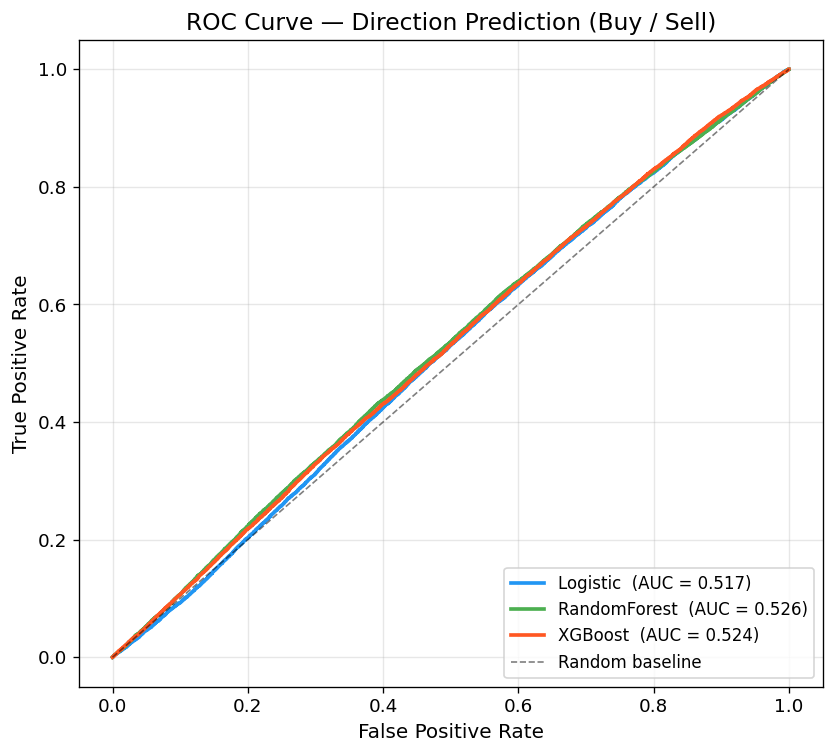

Saved → roc_curve_direction.png


In [53]:
# =====================================================
# PLOT 1 — ROC Curve with AUC (Direction Task)
# =====================================================
# Interpretation: ROC curves above the diagonal indicate
# discriminative power. For noisy financial data, AUC near
# 0.55–0.65 is realistic and suggests weak but non-trivial signal.

fig, ax = plt.subplots(figsize=(8, 7))

colors = {"Logistic": "#2196F3", "RandomForest": "#4CAF50", "XGBoost": "#FF5722"}

for name, model in direction_models.items():
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_direction, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=colors[name], lw=2.2,
            label=f"{name}  (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="Random baseline")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Direction Prediction (Buy / Sell)")
ax.legend(loc="lower right", fontsize=10)
ax.grid(alpha=0.3)

plt.savefig(f"{PLOT_DIR}/roc_curve_direction.png")
plt.show()
print("Saved → roc_curve_direction.png")


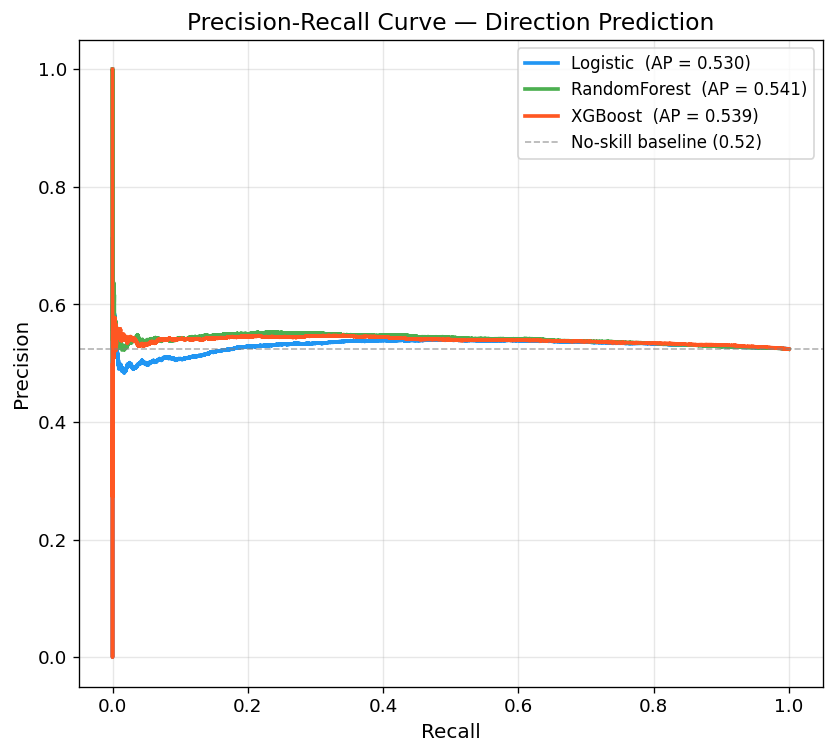

Saved → precision_recall_curve.png


In [54]:
# =====================================================
# PLOT 2 — Precision-Recall Curve (Direction Task)
# =====================================================
# Interpretation: PR curves are more informative than ROC when
# classes are moderately imbalanced. Higher AP indicates the
# model maintains precision as recall increases.

fig, ax = plt.subplots(figsize=(8, 7))

colors = {"Logistic": "#2196F3", "RandomForest": "#4CAF50", "XGBoost": "#FF5722"}

for name, model in direction_models.items():
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test_direction, y_prob)
    ap = average_precision_score(y_test_direction, y_prob)
    ax.plot(rec, prec, color=colors[name], lw=2.2,
            label=f"{name}  (AP = {ap:.3f})")

baseline = y_test_direction.mean()
ax.axhline(baseline, color="grey", ls="--", lw=1, alpha=0.6,
           label=f"No-skill baseline ({baseline:.2f})")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve — Direction Prediction")
ax.legend(loc="upper right", fontsize=10)
ax.grid(alpha=0.3)

plt.savefig(f"{PLOT_DIR}/precision_recall_curve.png")
plt.show()
print("Saved → precision_recall_curve.png")


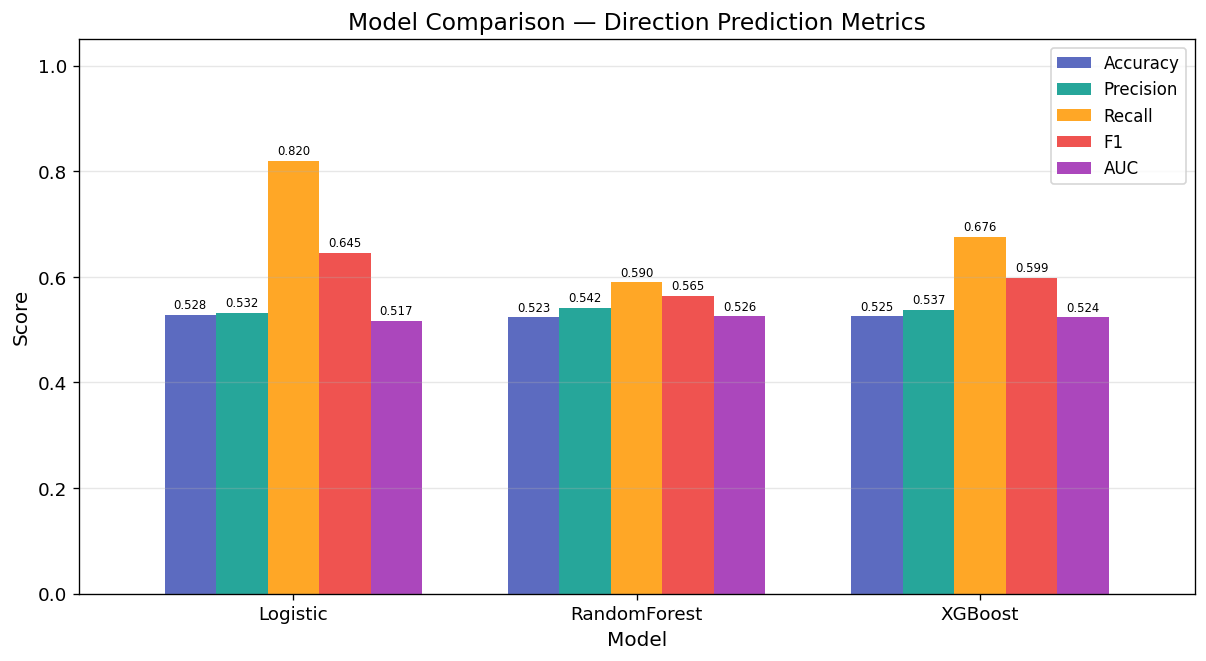

Saved → model_comparison_bar.png
              Accuracy  Precision  Recall      F1     AUC
Model                                                    
Logistic        0.5277     0.5321  0.8200  0.6454  0.5170
RandomForest    0.5232     0.5415  0.5897  0.5646  0.5256
XGBoost         0.5251     0.5374  0.6755  0.5986  0.5236


In [55]:
# =====================================================
# PLOT 3 — Model Comparison Bar Chart (Direction Task)
# =====================================================
# Interpretation: Comparing multiple metrics side-by-side exposes
# models that sacrifice recall for precision or vice versa.

metrics_data = []
for name, model in direction_models.items():
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    metrics_data.append({
        "Model": name,
        "Accuracy":  accuracy_score(y_test_direction, y_pred),
        "Precision": precision_score(y_test_direction, y_pred, zero_division=0),
        "Recall":    recall_score(y_test_direction, y_pred, zero_division=0),
        "F1":        f1_score(y_test_direction, y_pred, zero_division=0),
        "AUC":       roc_auc_score(y_test_direction, y_prob),
    })

comp_df = pd.DataFrame(metrics_data).set_index("Model")

fig, ax = plt.subplots(figsize=(12, 6))
comp_df.plot(kind="bar", ax=ax, width=0.75,
             color=["#5C6BC0", "#26A69A", "#FFA726", "#EF5350", "#AB47BC"])
ax.set_ylabel("Score")
ax.set_title("Model Comparison — Direction Prediction Metrics")
ax.set_ylim(0, 1.05)
ax.legend(loc="upper right", fontsize=10)
ax.set_xticklabels(comp_df.index, rotation=0)
ax.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=7, padding=2)

plt.savefig(f"{PLOT_DIR}/model_comparison_bar.png")
plt.show()
print("Saved → model_comparison_bar.png")
print(comp_df.round(4))


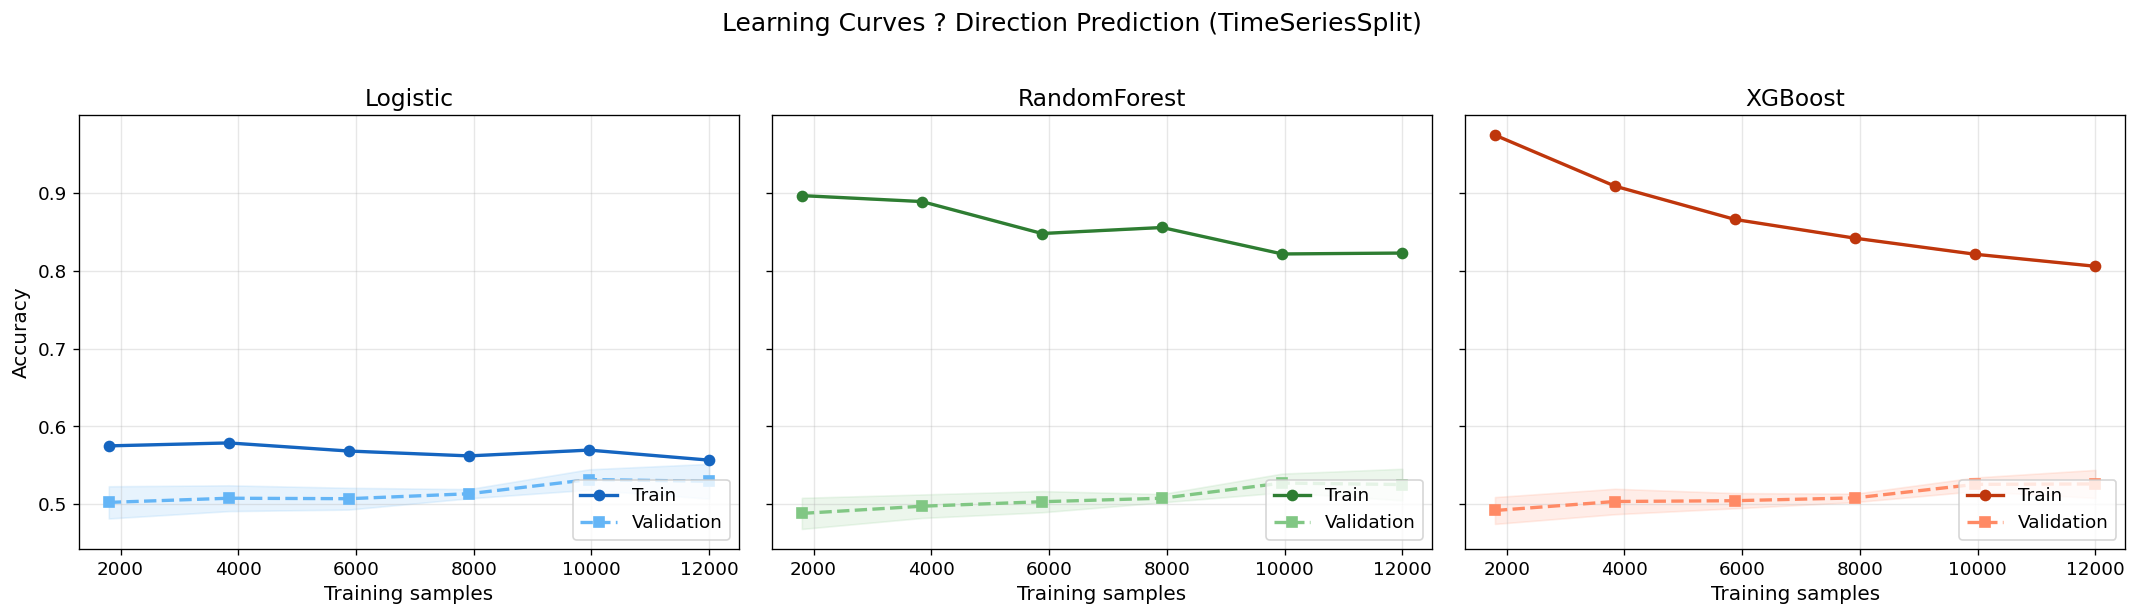

Saved ? learning_curves.png


In [56]:
# =====================================================
# PLOT 4 ? Learning Curves (Training vs Validation)
# =====================================================
# Interpretation: A large gap between train and validation scores
# signals overfitting; convergent curves suggest the model benefits
# from more data (underfitting regime).

from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

lc_models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(
        n_estimators=100, max_depth=12,
        min_samples_split=50, n_jobs=-1, random_state=42
    ),
    "XGBoost": XGBClassifier(
        objective="binary:logistic",
        n_estimators=200, max_depth=5,
        learning_rate=0.05, n_jobs=-1, random_state=42
    ),
}

colors_train = {"Logistic": "#1565C0", "RandomForest": "#2E7D32", "XGBoost": "#BF360C"}
colors_val   = {"Logistic": "#64B5F6", "RandomForest": "#81C784", "XGBoost": "#FF8A65"}

# Use TimeSeriesSplit to respect temporal ordering
ts_cv = TimeSeriesSplit(n_splits=4)

# Sub-sample to keep runtime manageable
n_sub = min(60000, len(X_train_scaled))
X_lc = X_train_scaled[:n_sub]
y_lc = y_train_direction.values[:n_sub]

for ax, (name, model) in zip(axes, lc_models.items()):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_lc, y_lc,
        train_sizes=np.linspace(0.15, 1.0, 6),
        cv=ts_cv, scoring="accuracy", n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                     alpha=0.15, color=colors_train[name])
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                     alpha=0.15, color=colors_val[name])

    ax.plot(train_sizes, train_mean, "o-", color=colors_train[name],
            lw=2, label="Train")
    ax.plot(train_sizes, val_mean, "s--", color=colors_val[name],
            lw=2, label="Validation")

    ax.set_title(name)
    ax.set_xlabel("Training samples")
    ax.legend(loc="lower right")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Accuracy")
fig.suptitle("Learning Curves ? Direction Prediction (TimeSeriesSplit)", fontsize=15, y=1.02)
plt.tight_layout()

plt.savefig(f"{PLOT_DIR}/learning_curves.png")
plt.show()
print("Saved ? learning_curves.png")


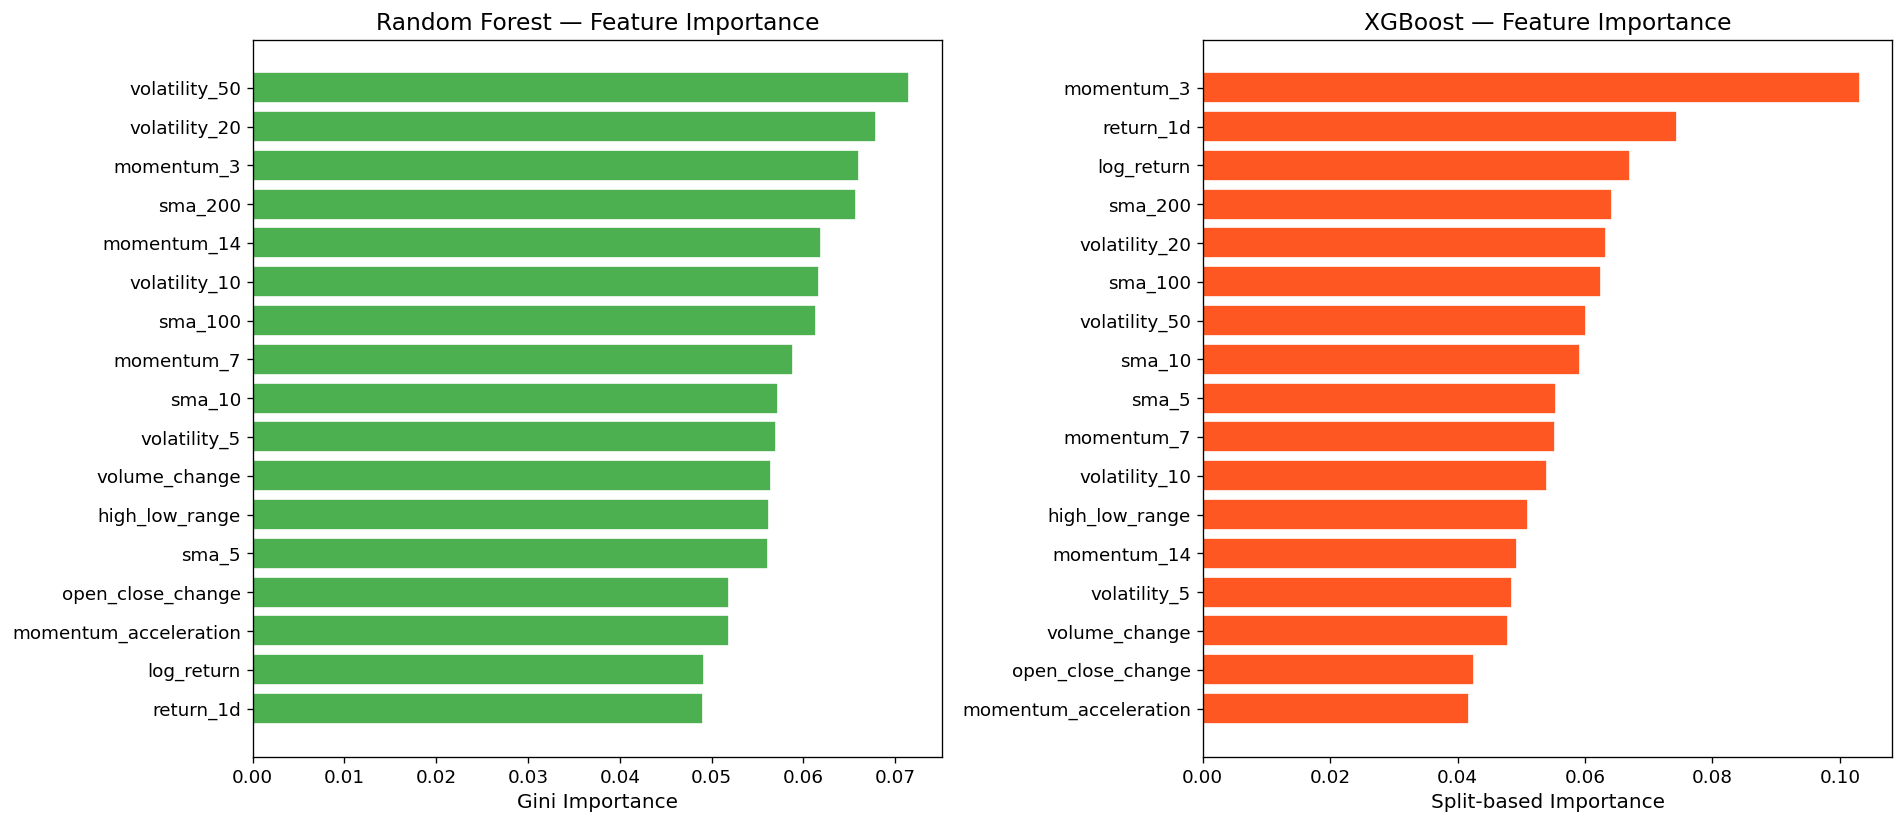

Saved → feature_importance.png


In [57]:
# =====================================================
# PLOT 5 — Feature Importance (Random Forest & XGBoost)
# =====================================================
# Interpretation: Dominant features in financial models are
# typically momentum and volatility indicators.  If a raw price
# feature dominates, it may indicate scale leakage.

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

feat_names = feature_columns_clean

# Random Forest importances
rf_imp = rf_dir.feature_importances_
rf_order = np.argsort(rf_imp)

axes[0].barh(np.array(feat_names)[rf_order], rf_imp[rf_order],
             color="#4CAF50", edgecolor="white")
axes[0].set_title("Random Forest — Feature Importance")
axes[0].set_xlabel("Gini Importance")

# XGBoost importances
xgb_imp = xgb_dir.feature_importances_
xgb_order = np.argsort(xgb_imp)

axes[1].barh(np.array(feat_names)[xgb_order], xgb_imp[xgb_order],
             color="#FF5722", edgecolor="white")
axes[1].set_title("XGBoost — Feature Importance")
axes[1].set_xlabel("Split-based Importance")

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/feature_importance.png")
plt.show()
print("Saved → feature_importance.png")


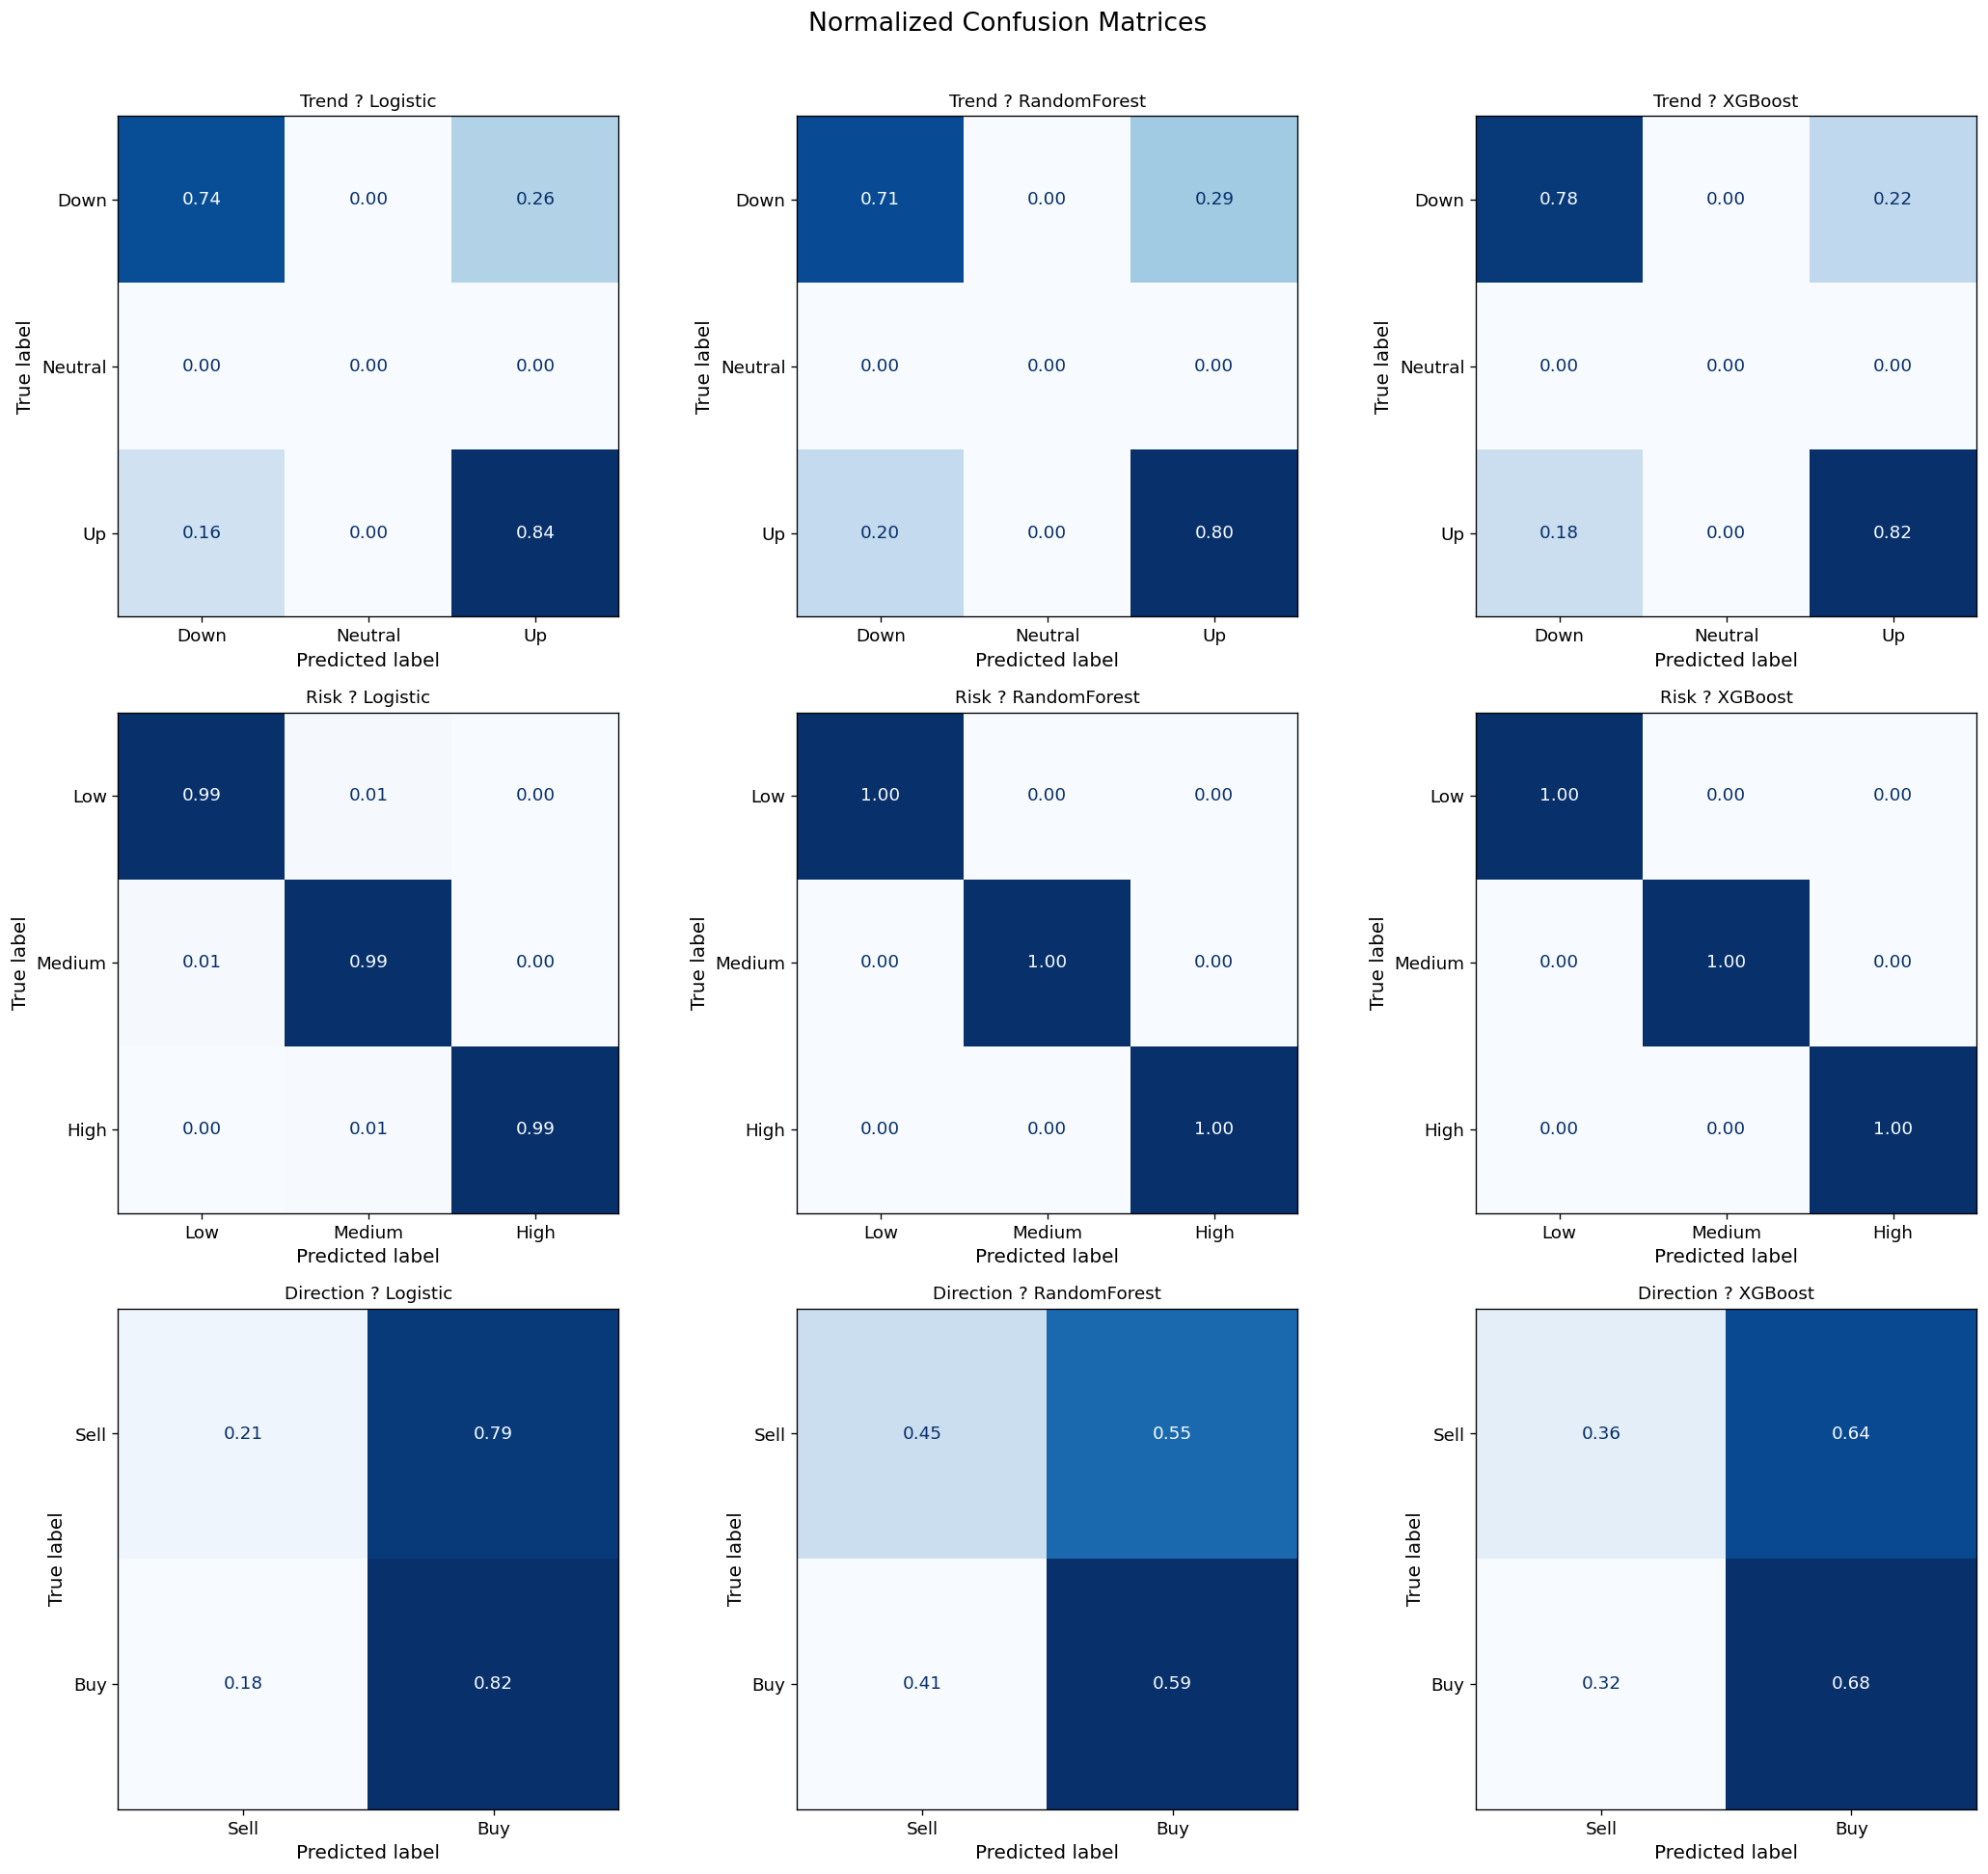

Saved ? confusion_matrices_normalized.png


In [58]:
# =====================================================
# PLOT 6 ? Normalized Confusion Matrices (All 3 Tasks)
# =====================================================
# Interpretation: Normalized matrices reveal per-class recall.
# For financial tasks, off-diagonal mass quantifies the cost
# of mis-classification (e.g., calling a Sell a Buy).

fig, axes = plt.subplots(3, 3, figsize=(18, 16))

task_configs = [
    ("Trend",     y_test_trend,     trend_models,     ["Down", "Neutral", "Up"], [0, 1, 2]),
    ("Risk",      y_test_risk,      risk_models,      ["Low", "Medium", "High"], [0, 1, 2]),
    ("Direction", y_test_direction, direction_models, ["Sell", "Buy"], [0, 1]),
]

for row, (task_name, y_true, models_dict, class_names, label_ids) in enumerate(task_configs):
    for col, (model_name, model) in enumerate(models_dict.items()):
        y_p = model.predict(X_test_scaled)
        cm = confusion_matrix(y_true, y_p, labels=label_ids, normalize="true")
        disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
        disp.plot(
            ax=axes[row, col],
            cmap="Blues",
            values_format=".2f",
            colorbar=False,
        )
        axes[row, col].set_title(f"{task_name} ? {model_name}", fontsize=11)

plt.suptitle("Normalized Confusion Matrices", fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/confusion_matrices_normalized.png")
plt.show()
print("Saved ? confusion_matrices_normalized.png")


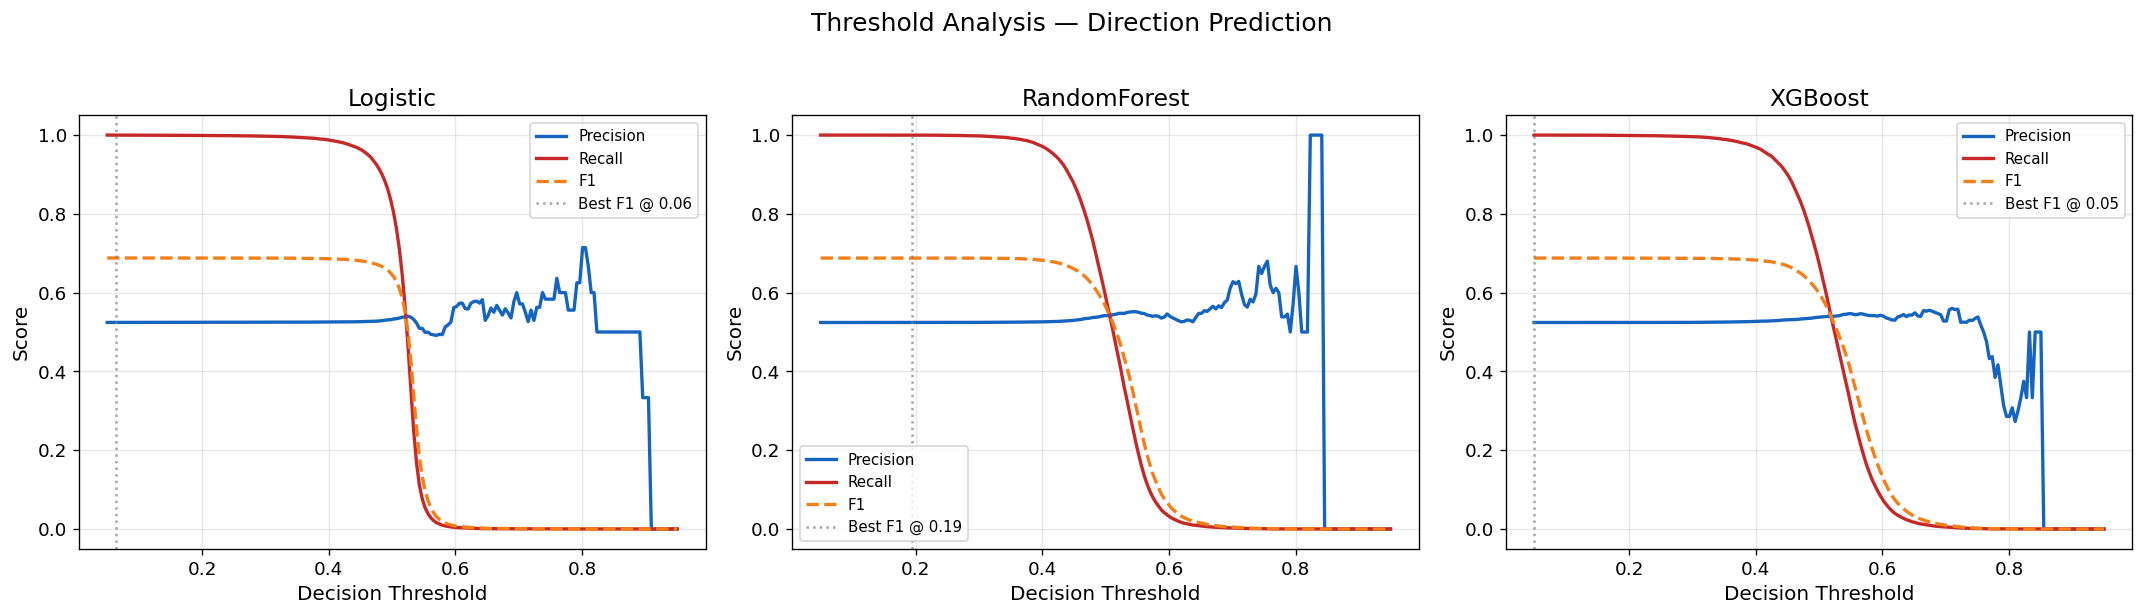

Saved → threshold_analysis.png


In [59]:
# =====================================================
# PLOT 7 — Threshold vs Precision / Recall / F1
# =====================================================
# Interpretation: This reveals the decision-threshold sensitivity
# of the best model.  In quant finance, adjusting the threshold
# shifts the risk-reward trade-off of the trading signal.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = {"Logistic": "#2196F3", "RandomForest": "#4CAF50", "XGBoost": "#FF5722"}

for ax, (name, model) in zip(axes, direction_models.items()):
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    thresholds = np.linspace(0.05, 0.95, 200)

    precs, recs, f1s = [], [], []
    for t in thresholds:
        y_hat = (y_prob >= t).astype(int)
        precs.append(precision_score(y_test_direction, y_hat, zero_division=0))
        recs.append(recall_score(y_test_direction, y_hat, zero_division=0))
        f1s.append(f1_score(y_test_direction, y_hat, zero_division=0))

    ax.plot(thresholds, precs, label="Precision", color="#1565C0", lw=2)
    ax.plot(thresholds, recs,  label="Recall",    color="#C62828", lw=2)
    ax.plot(thresholds, f1s,   label="F1",        color="#F57F17", lw=2, ls="--")

    best_idx = np.argmax(f1s)
    ax.axvline(thresholds[best_idx], color="grey", ls=":", alpha=0.7,
               label=f"Best F1 @ {thresholds[best_idx]:.2f}")

    ax.set_title(f"{name}")
    ax.set_xlabel("Decision Threshold")
    ax.set_ylabel("Score")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

fig.suptitle("Threshold Analysis — Direction Prediction", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/threshold_analysis.png")
plt.show()
print("Saved → threshold_analysis.png")


Logistic: 0.5142 ? 0.0303
RandomForest: 0.5252 ? 0.0170
XGBoost: 0.5252 ? 0.0171


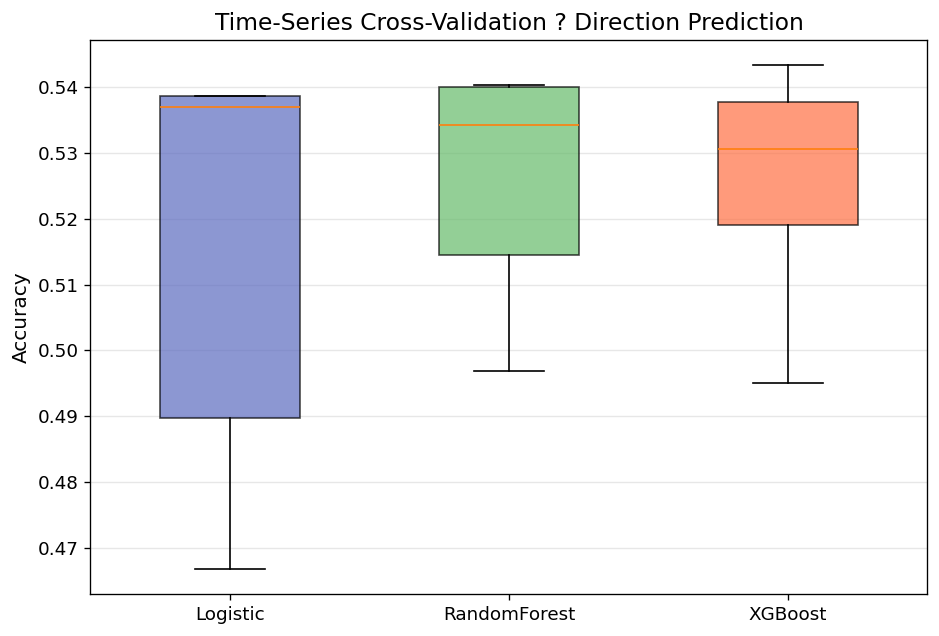

Saved ? cross_validation_boxplot.png


In [60]:
# =====================================================
# PLOT 8 ? Cross-Validation Performance (TimeSeriesSplit)
# =====================================================
# Interpretation: TimeSeriesSplit prevents future-data leakage.
# Box-plots show performance variance across temporal folds,
# indicating model stability over different market regimes.

from sklearn.model_selection import cross_val_score, TimeSeriesSplit

ts_cv = TimeSeriesSplit(n_splits=5)

n_sub = min(80000, len(X_train_scaled))
X_cv = X_train_scaled[:n_sub]
y_cv = y_train_direction.values[:n_sub]

cv_models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(
        n_estimators=100, max_depth=12,
        min_samples_split=50, n_jobs=-1, random_state=42
    ),
    "XGBoost": XGBClassifier(
        objective="binary:logistic",
        n_estimators=200, max_depth=5,
        learning_rate=0.05, n_jobs=-1, random_state=42
    ),
}

cv_results = {}
for name, model in cv_models.items():
    scores = cross_val_score(model, X_cv, y_cv, cv=ts_cv,
                             scoring="accuracy", n_jobs=-1)
    cv_results[name] = scores
    print(f"{name}: {scores.mean():.4f} ? {scores.std():.4f}")

fig, ax = plt.subplots(figsize=(9, 6))

bp = ax.boxplot(
    [cv_results[n] for n in cv_results],
    labels=list(cv_results.keys()),
    patch_artist=True,
    widths=0.5,
)

box_colors = ["#5C6BC0", "#66BB6A", "#FF7043"]
for patch, c in zip(bp["boxes"], box_colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.7)

ax.set_ylabel("Accuracy")
ax.set_title("Time-Series Cross-Validation ? Direction Prediction")
ax.grid(axis="y", alpha=0.3)

plt.savefig(f"{PLOT_DIR}/cross_validation_boxplot.png")
plt.show()
print("Saved ? cross_validation_boxplot.png")


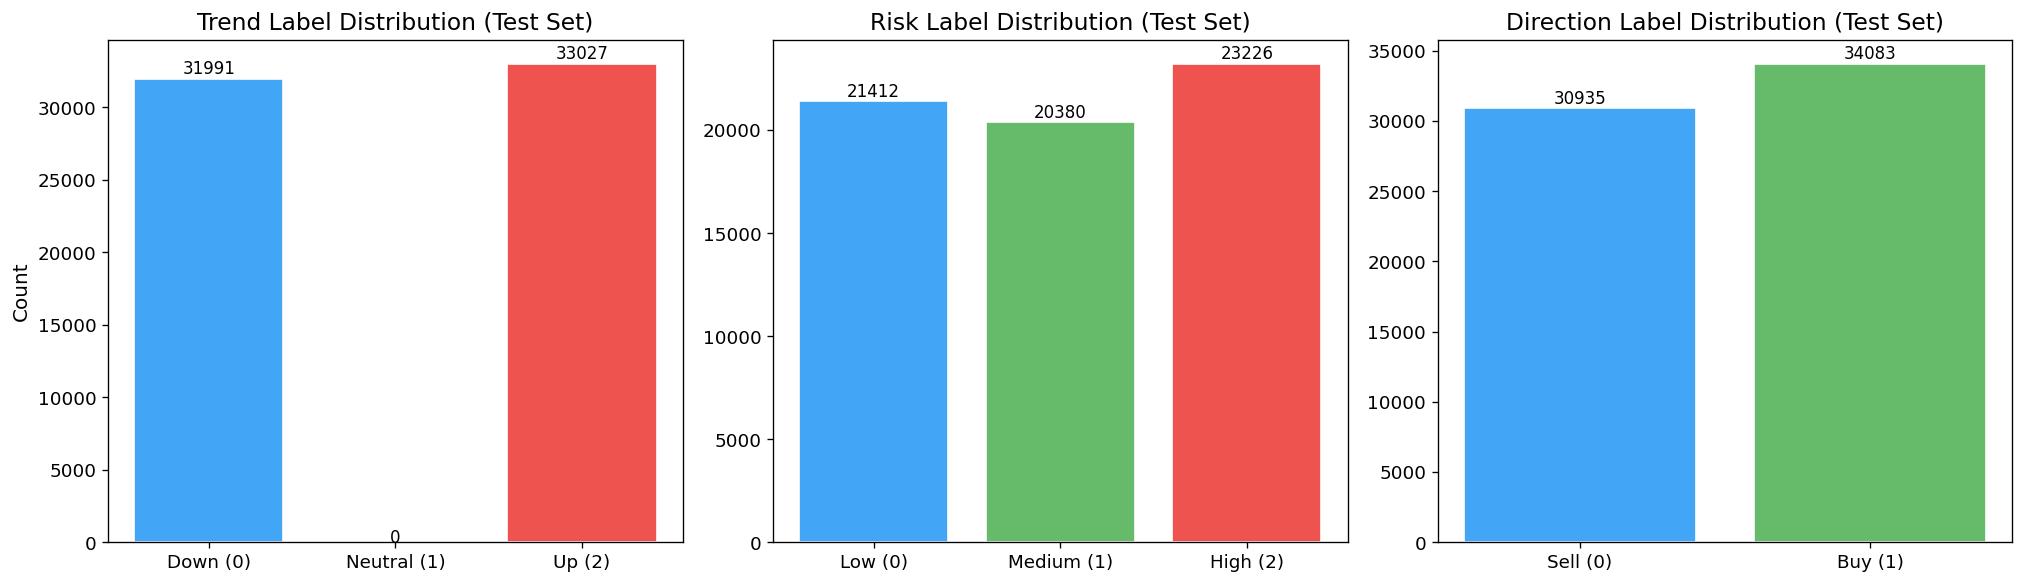

Saved → class_distribution.png


In [62]:
# =====================================================
# PLOT 9 — Class Distribution (Trend, Risk, Direction)
# =====================================================

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

palette = ["#42A5F5", "#66BB6A", "#EF5350"]

# Trend
trend_counts = y_test_trend.value_counts().sort_index().reindex([0, 1, 2], fill_value=0)
axes[0].bar(["Down (0)", "Neutral (1)", "Up (2)"],
            trend_counts.values, color=palette, edgecolor="white")
axes[0].set_title("Trend Label Distribution (Test Set)")
axes[0].set_ylabel("Count")
for i, v in enumerate(trend_counts.values):
    axes[0].text(i, v + max(v * 0.01, 1), str(v), ha="center", fontsize=10)

# Risk
risk_counts = y_test_risk.value_counts().sort_index().reindex([0, 1, 2], fill_value=0)
axes[1].bar(["Low (0)", "Medium (1)", "High (2)"],
            risk_counts.values, color=palette, edgecolor="white")
axes[1].set_title("Risk Label Distribution (Test Set)")
for i, v in enumerate(risk_counts.values):
    axes[1].text(i, v + max(v * 0.01, 1), str(v), ha="center", fontsize=10)

# Direction
dir_counts = y_test_direction.value_counts().sort_index().reindex([0, 1], fill_value=0)
axes[2].bar(["Sell (0)", "Buy (1)"],
            dir_counts.values, color=palette[:2], edgecolor="white")
axes[2].set_title("Direction Label Distribution (Test Set)")
for i, v in enumerate(dir_counts.values):
    axes[2].text(i, v + max(v * 0.01, 1), str(v), ha="center", fontsize=10)

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/class_distribution.png")
plt.show()
print("Saved → class_distribution.png")


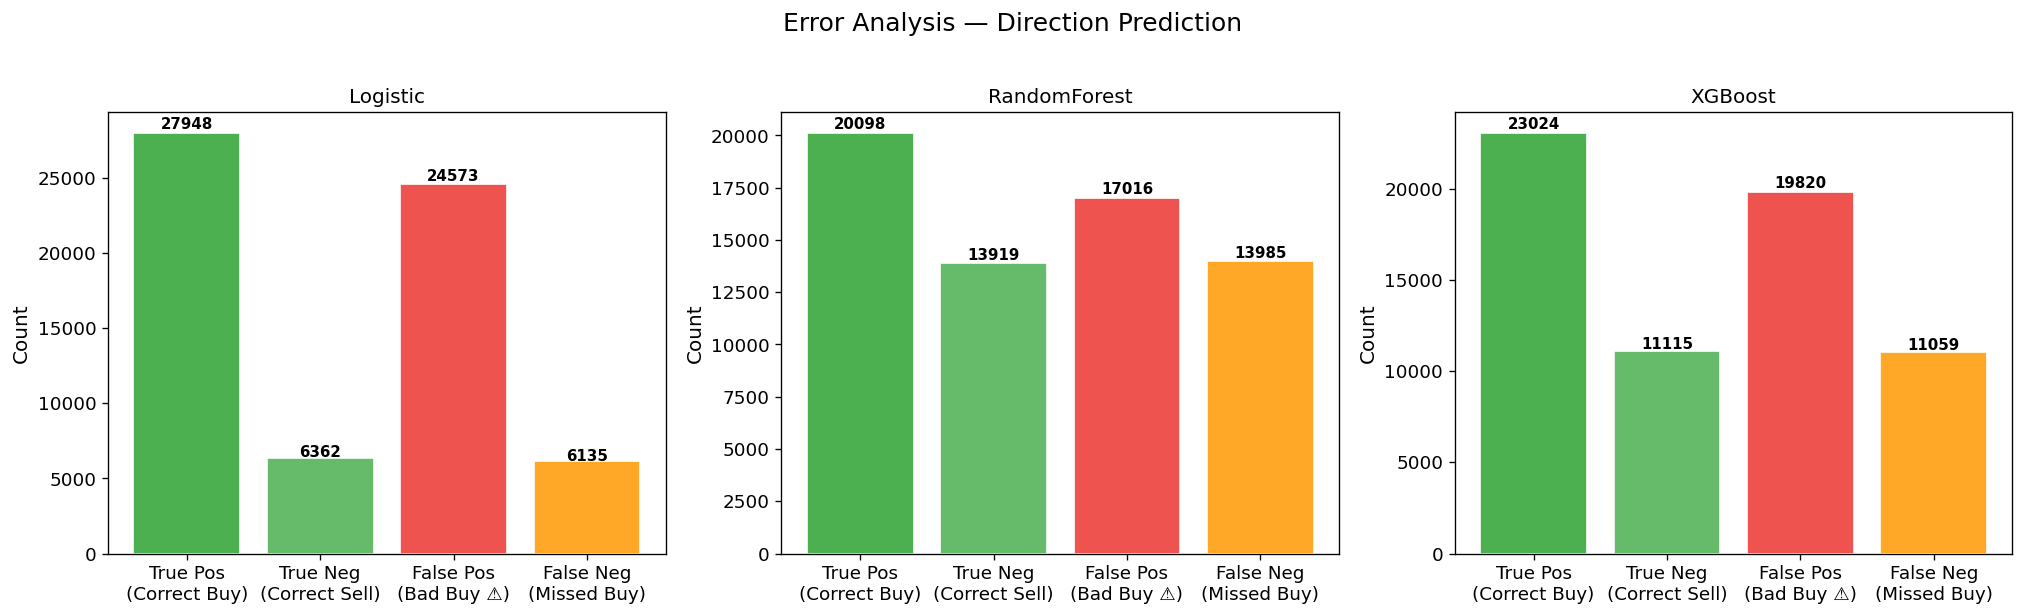

Saved → error_analysis_fp_fn.png


In [63]:
# =====================================================
# PLOT 10 — Error Analysis: False Positives vs False Negatives
# =====================================================
# Interpretation: In trading, False Positives (predict Buy → actual Sell)
# lead to direct losses, while False Negatives (predict Sell → actual Buy)
# represent missed opportunity.  The asymmetry matters for portfolio risk.

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, (name, model) in zip(axes, direction_models.items()):
    y_pred = model.predict(X_test_scaled)
    y_true = y_test_direction.values

    TP = ((y_pred == 1) & (y_true == 1)).sum()
    TN = ((y_pred == 0) & (y_true == 0)).sum()
    FP = ((y_pred == 1) & (y_true == 0)).sum()
    FN = ((y_pred == 0) & (y_true == 1)).sum()

    categories = ["True Pos\n(Correct Buy)", "True Neg\n(Correct Sell)",
                  "False Pos\n(Bad Buy ⚠️)", "False Neg\n(Missed Buy)"]
    values = [TP, TN, FP, FN]
    colors_err = ["#4CAF50", "#66BB6A", "#EF5350", "#FFA726"]

    bars = ax.bar(categories, values, color=colors_err, edgecolor="white")
    ax.set_title(f"{name}", fontsize=12)
    ax.set_ylabel("Count")

    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, v + v*0.01,
                str(v), ha="center", fontsize=9, fontweight="bold")

fig.suptitle("Error Analysis — Direction Prediction", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/error_analysis_fp_fn.png")
plt.show()
print("Saved → error_analysis_fp_fn.png")


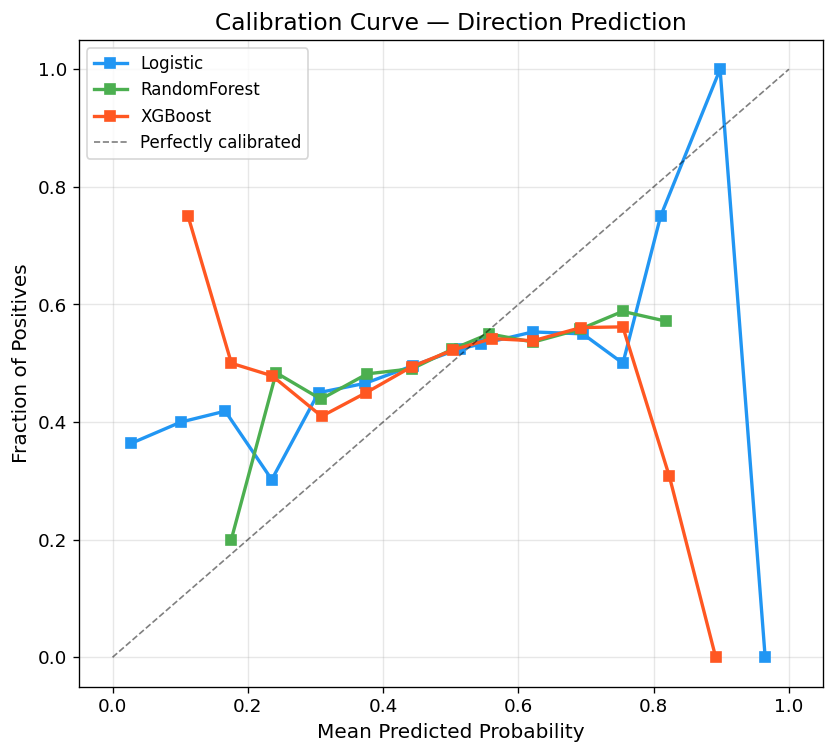

Saved → calibration_curve.png


In [64]:
# =====================================================
# PLOT 11 — Calibration Curve (Direction Task)
# =====================================================
# Interpretation: A well-calibrated model's predicted probabilities
# match observed frequencies.  Over-confidence (curve above diagonal)
# is common with tree models on noisy data.

fig, ax = plt.subplots(figsize=(8, 7))

colors = {"Logistic": "#2196F3", "RandomForest": "#4CAF50", "XGBoost": "#FF5722"}

for name, model in direction_models.items():
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fraction_pos, mean_pred = calibration_curve(
        y_test_direction, y_prob, n_bins=15, strategy="uniform"
    )
    ax.plot(mean_pred, fraction_pos, "s-", color=colors[name],
            lw=2, label=name)

ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="Perfectly calibrated")
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Fraction of Positives")
ax.set_title("Calibration Curve — Direction Prediction")
ax.legend(loc="upper left", fontsize=10)
ax.grid(alpha=0.3)

plt.savefig(f"{PLOT_DIR}/calibration_curve.png")
plt.show()
print("Saved → calibration_curve.png")


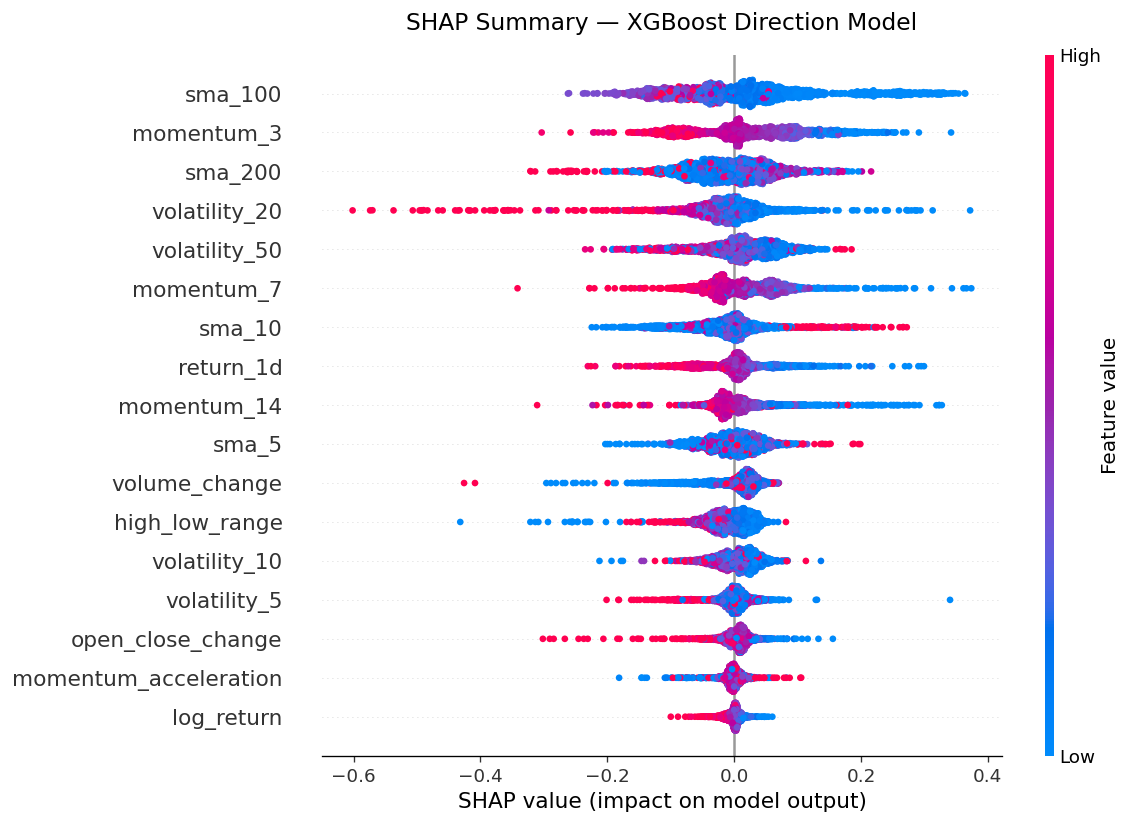

Saved → shap_summary.png


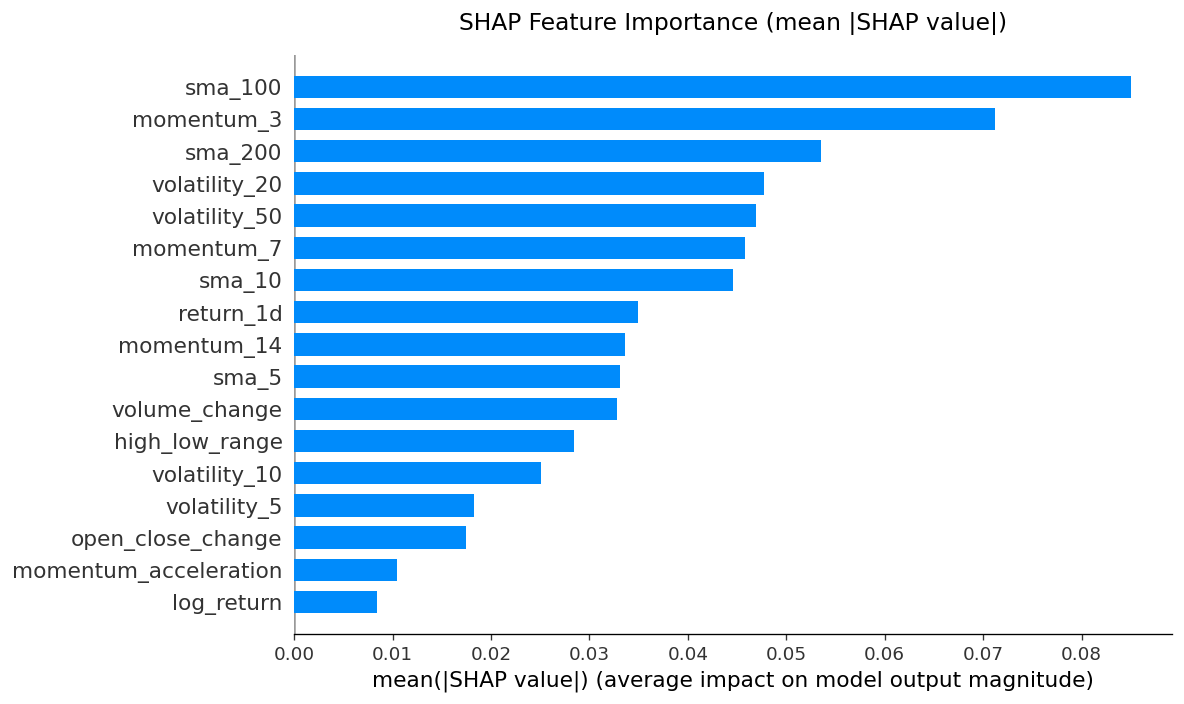

Saved → shap_bar_importance.png


In [65]:
# =====================================================
# PLOT 12 — SHAP Explainability (Best Model — XGBoost)
# =====================================================
# Interpretation: SHAP values decompose each prediction into
# feature contributions.  In quant finance, this reveals which
# technical indicators actually drive buy/sell signals vs. noise.

# Use a sub-sample for SHAP to keep runtime reasonable
shap_sample_size = min(2000, len(X_test_scaled))
X_shap = X_test_scaled[:shap_sample_size]

explainer = shap.TreeExplainer(xgb_dir)
shap_values = explainer.shap_values(X_shap)

# Summary beeswarm plot
fig = plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_shap,
    feature_names=feature_columns_clean,
    plot_type="dot",
    show=False,
    plot_size=(10, 7)
)
plt.title("SHAP Summary — XGBoost Direction Model", fontsize=14, pad=15)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/shap_summary.png")
plt.show()
print("Saved → shap_summary.png")

# Bar summary (mean |SHAP|)
fig = plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values, X_shap,
    feature_names=feature_columns_clean,
    plot_type="bar",
    show=False,
    plot_size=(10, 6)
)
plt.title("SHAP Feature Importance (mean |SHAP value|)", fontsize=14, pad=15)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/shap_bar_importance.png")
plt.show()
print("Saved → shap_bar_importance.png")


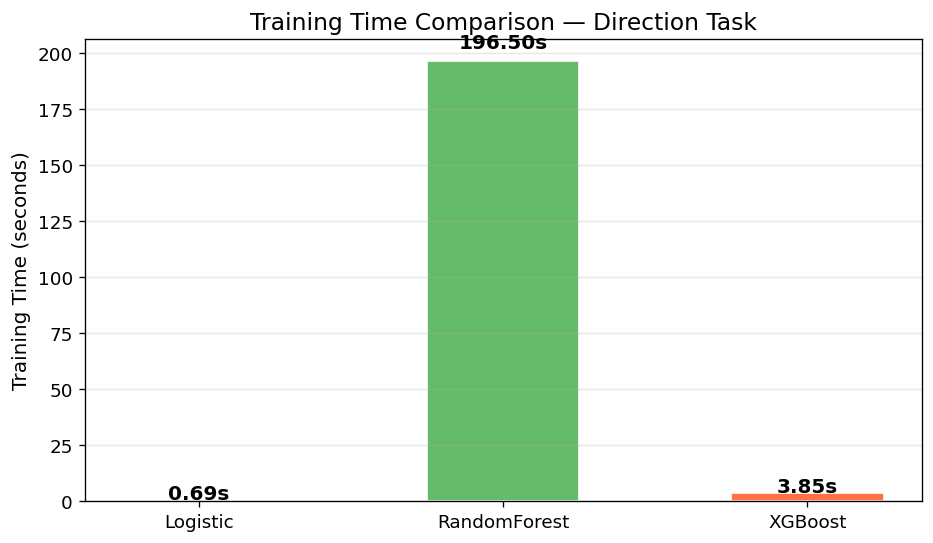

Saved → training_time_comparison.png

📊 ALL 13 ADVANCED PLOTS GENERATED SUCCESSFULLY
Saved to: /kaggle/working/plots
  ✅ calibration_curve.png
  ✅ class_distribution.png
  ✅ confusion_matrices_normalized.png
  ✅ cross_validation_boxplot.png
  ✅ error_analysis_fp_fn.png
  ✅ feature_importance.png
  ✅ learning_curves.png
  ✅ model_comparison_bar.png
  ✅ precision_recall_curve.png
  ✅ roc_curve_direction.png
  ✅ shap_bar_importance.png
  ✅ shap_summary.png
  ✅ threshold_analysis.png
  ✅ training_time_comparison.png

Total plots: 14


In [66]:
# =====================================================
# PLOT 13 — Training Time Comparison
# =====================================================
# Interpretation: Training cost matters for production deployment.
# Logistic Regression trains orders of magnitude faster than
# ensemble methods, making it attractive for high-frequency
# retraining workflows.

# If xgb_direction was reused from STEP 22, measure fresh training time
if _train_times.get("XGBoost", 0) == 0:
    _xgb_tmp = XGBClassifier(
        objective="binary:logistic", n_estimators=400, max_depth=5,
        learning_rate=0.05, subsample=0.8,
        colsample_bytree=0.8, random_state=42, n_jobs=-1
    )
    _t0 = _time.time()
    _xgb_tmp.fit(X_train_scaled, y_train_direction)
    _train_times["XGBoost"] = _time.time() - _t0

fig, ax = plt.subplots(figsize=(9, 5))

model_names = list(_train_times.keys())
times = [_train_times[n] for n in model_names]
bar_colors = ["#5C6BC0", "#66BB6A", "#FF7043"]

bars = ax.bar(model_names, times, color=bar_colors, edgecolor="white", width=0.5)

for bar, t in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2, t + t*0.03,
            f"{t:.2f}s", ha="center", fontsize=12, fontweight="bold")

ax.set_ylabel("Training Time (seconds)")
ax.set_title("Training Time Comparison — Direction Task")
ax.grid(axis="y", alpha=0.3)

plt.savefig(f"{PLOT_DIR}/training_time_comparison.png")
plt.show()
print("Saved → training_time_comparison.png")

# Final summary
print("\n" + "="*60)
print("📊 ALL 13 ADVANCED PLOTS GENERATED SUCCESSFULLY")
print("="*60)
print(f"Saved to: {PLOT_DIR}")

import glob as _glob
saved_files = sorted(_glob.glob(f"{PLOT_DIR}/*.png"))
for f in saved_files:
    print(f"  ✅ {os.path.basename(f)}")
print(f"\nTotal plots: {len(saved_files)}")


# Kaggle Production Inference Integration

This section keeps the original notebook intact and adds a production-ready inference pipeline that:

- preserves the original training workflow
- reuses the notebook-trained models
- rebuilds the correct clean-feature scaler for inference
- fetches live OHLCV data with `yfinance`
- reproduces the same feature engineering pipeline used in training
- returns Trend, Risk, and Direction predictions with probabilities


In [68]:
import importlib
import subprocess
import sys

for package in ['yfinance', 'joblib']:
    try:
        importlib.import_module(package)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])

print('Inference dependencies are ready.')


Inference dependencies are ready.


In [69]:
import json
import pickle
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

MODEL_DIR = Path('/kaggle/working/models')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

TREND_LABELS = {0: 'Downtrend', 1: 'Sideways', 2: 'Uptrend'}
RISK_LABELS = {0: 'Low Risk', 1: 'Medium Risk', 2: 'High Risk'}
DIRECTION_LABELS = {0: 'Sell', 1: 'Buy'}

ALL_ENGINEERED_FEATURES = [
    'return_1d',
    'log_return',
    'high_low_range',
    'open_close_change',
    'volume_change',
    'sma_5',
    'sma_10',
    'sma_20',
    'sma_50',
    'sma_100',
    'sma_200',
    'volatility_5',
    'volatility_10',
    'volatility_20',
    'volatility_50',
    'momentum_3',
    'momentum_7',
    'momentum_14',
    'momentum_acceleration',
]


def build_production_scaler(train_data, feature_order):
    # The notebook later overwrites `scaler` during the binary trend step,
    # so we rebuild the correct StandardScaler on the final clean features.
    scaler = StandardScaler()
    scaler.fit(train_data[feature_order])
    return scaler


def ensure_trend_model_3class(train_data, feature_order, y_train_trend, scaler, trend_model=None):
    # Production requires 3-class trend prediction. If the notebook already
    # created `xgb_trend_3c`, we reuse it. Otherwise we train it here using
    # the same clean feature set and XGBoost settings used in the notebook.
    if trend_model is not None:
        return trend_model

    x_train = scaler.transform(train_data[feature_order])
    trend_model = XGBClassifier(
        objective='multi:softprob',
        num_class=3,
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
    )
    trend_model.fit(x_train, y_train_trend)
    return trend_model


def save_notebook_artifacts(
    train_data,
    feature_columns_clean,
    y_train_trend,
    risk_model,
    direction_model,
    trend_model=None,
):
    feature_order = list(feature_columns_clean)
    production_scaler = build_production_scaler(train_data, feature_order)
    trend_model = ensure_trend_model_3class(
        train_data=train_data,
        feature_order=feature_order,
        y_train_trend=y_train_trend,
        scaler=production_scaler,
        trend_model=trend_model,
    )

    joblib.dump(trend_model, MODEL_DIR / 'trend_model.pkl')
    joblib.dump(risk_model, MODEL_DIR / 'risk_model.pkl')
    joblib.dump(direction_model, MODEL_DIR / 'direction_model.pkl')
    joblib.dump(production_scaler, MODEL_DIR / 'scaler.pkl')

    metadata = {
        'feature_order': feature_order,
        'all_engineered_features': ALL_ENGINEERED_FEATURES,
        'trend_label_map': TREND_LABELS,
        'risk_label_map': RISK_LABELS,
        'direction_label_map': DIRECTION_LABELS,
    }
    with open(MODEL_DIR / 'pipeline_metadata.pkl', 'wb') as f:
        pickle.dump(metadata, f)

    print(f'Artifacts saved to: {MODEL_DIR}')


def load_models(model_dir=MODEL_DIR):
    trend_model = joblib.load(model_dir / 'trend_model.pkl')
    risk_model = joblib.load(model_dir / 'risk_model.pkl')
    direction_model = joblib.load(model_dir / 'direction_model.pkl')
    scaler = joblib.load(model_dir / 'scaler.pkl')

    with open(model_dir / 'pipeline_metadata.pkl', 'rb') as f:
        metadata = pickle.load(f)

    return {
        'trend_model': trend_model,
        'risk_model': risk_model,
        'direction_model': direction_model,
        'scaler': scaler,
        'feature_order': metadata['feature_order'],
        'metadata': metadata,
    }


def fetch_stock_data(ticker):
    if not isinstance(ticker, str) or not ticker.strip():
        raise ValueError('Ticker must be a non-empty string.')

    ticker = ticker.strip().upper()
    df = yf.download(
        ticker,
        period='3y',
        interval='1d',
        auto_adjust=False,
        progress=False,
        threads=False,
    )

    if df is None or df.empty:
        raise ValueError(f'No data returned for ticker: {ticker}')

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [col[0] for col in df.columns]

    df = df.reset_index()

    if 'Adj Close' in df.columns:
        df = df.drop(columns=['Adj Close'])
    if 'OpenInt' in df.columns:
        df = df.drop(columns=['OpenInt'])

    required_cols = ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']
    missing_cols = sorted(set(required_cols) - set(df.columns))
    if missing_cols:
        raise ValueError(f'Missing required columns: {missing_cols}')

    df = df[required_cols].copy()
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df = df.dropna(subset=required_cols).sort_values('Date').reset_index(drop=True)
    df['ticker'] = ticker

    if len(df) < 200:
        raise ValueError(
            f"Ticker '{ticker}' has only {len(df)} valid rows. At least 200 rows are required for SMA200."
        )

    return df


def create_features(df):
    # This exactly mirrors the original notebook's feature engineering and
    # only uses current/past values, which keeps inference leakage-free.
    df = df.copy()
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df = df.dropna(subset=['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'ticker'])
    df = df.sort_values(['ticker', 'Date']).reset_index(drop=True)

    df['return_1d'] = df.groupby('ticker')['Close'].pct_change()
    df['log_return'] = np.log(df['Close'] / df.groupby('ticker')['Close'].shift(1))

    df['high_low_range'] = (df['High'] - df['Low']) / df['Close']
    df['open_close_change'] = (df['Close'] - df['Open']) / df['Open']

    df['volume_change'] = df.groupby('ticker')['Volume'].pct_change()

    for window in [5, 10, 20, 50, 100, 200]:
        df[f'sma_{window}'] = (
            df.groupby('ticker')['Close']
            .transform(lambda x: x.rolling(window).mean())
        )

    for window in [5, 10, 20, 50]:
        df[f'volatility_{window}'] = (
            df.groupby('ticker')['return_1d']
            .transform(lambda x: x.rolling(window).std())
        )

    df['momentum_3'] = df.groupby('ticker')['Close'].pct_change(3)
    df['momentum_7'] = df.groupby('ticker')['Close'].pct_change(7)
    df['momentum_14'] = df.groupby('ticker')['Close'].pct_change(14)
    df['momentum_acceleration'] = df['momentum_7'] - df['momentum_3']

    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=ALL_ENGINEERED_FEATURES).reset_index(drop=True)

    if df.empty:
        raise ValueError('No rows remain after feature generation.')

    keep_cols = ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'ticker'] + ALL_ENGINEERED_FEATURES
    return df[keep_cols].copy()


def scale_features(df, model_dir=MODEL_DIR):
    artifacts = load_models(model_dir=model_dir)
    scaler = artifacts['scaler']
    feature_order = artifacts['feature_order']

    missing_cols = sorted(set(feature_order) - set(df.columns))
    if missing_cols:
        raise ValueError(f'Missing required model features: {missing_cols}')

    x = df[feature_order].copy()
    x_scaled = scaler.transform(x)
    return pd.DataFrame(x_scaled, columns=feature_order, index=df.index)


def _format_prediction(model, latest_row, label_map):
    if not hasattr(model, 'predict_proba'):
        raise TypeError(f'{type(model).__name__} does not support predict_proba().')

    probs = model.predict_proba(latest_row)[0]
    classes = getattr(model, 'classes_', np.arange(len(probs)))
    classes = [int(c) for c in classes]

    best_idx = int(np.argmax(probs))
    pred_class = classes[best_idx]
    pred_prob = float(probs[best_idx])

    return {
        'class': pred_class,
        'label': label_map[pred_class],
        'probability': round(pred_prob, 4),
        'confidence': round(pred_prob, 4),
        'all_probabilities': {
            label_map[int(c)]: round(float(p), 4)
            for c, p in zip(classes, probs)
            if int(c) in label_map
        },
    }


def predict_stock(ticker, model_dir=MODEL_DIR):
    try:
        artifacts = load_models(model_dir=model_dir)
        raw_df = fetch_stock_data(ticker)
        feature_df = create_features(raw_df)
        scaled_df = scale_features(feature_df, model_dir=model_dir)
        latest_row = scaled_df.iloc[[-1]]

        return {
            'ticker': ticker.strip().upper(),
            'trend_prediction': _format_prediction(artifacts['trend_model'], latest_row, TREND_LABELS),
            'risk_prediction': _format_prediction(artifacts['risk_model'], latest_row, RISK_LABELS),
            'direction_prediction': _format_prediction(artifacts['direction_model'], latest_row, DIRECTION_LABELS),
        }
    except Exception as exc:
        return {
            'ticker': ticker.strip().upper() if isinstance(ticker, str) else str(ticker),
            'error': str(exc),
        }


def print_prediction(result):
    print(json.dumps(result, indent=2))


def plot_last_200_days(ticker):
    import matplotlib.pyplot as plt

    df = fetch_stock_data(ticker).tail(200).copy()
    plt.figure(figsize=(12, 5))
    plt.plot(df['Date'], df['Close'], linewidth=2)
    plt.title(f'{ticker.upper()} - Last 200 Trading Days')
    plt.xlabel('Date')
    plt.ylabel('Close Price')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


artifact_paths = save_notebook_artifacts(
    train_data=train_data,
    feature_columns_clean=feature_columns_clean,
    y_train_trend=y_train_trend,
    trend_model=globals().get('xgb_trend_3c'),
    risk_model=xgb_risk,
    direction_model=xgb_direction,
)
artifact_paths


Artifacts saved to: /kaggle/working/models


In [70]:
# Example inference
result = predict_stock('AAPL')
print_prediction(result)
result


{
  "ticker": "AAPL",
  "trend_prediction": {
    "class": 2,
    "label": "Uptrend",
    "probability": 0.7394,
    "confidence": 0.7394,
    "all_probabilities": {
      "Downtrend": 0.2606,
      "Sideways": 0.0,
      "Uptrend": 0.7394
    }
  },
  "risk_prediction": {
    "class": 0,
    "label": "Low Risk",
    "probability": 1.0,
    "confidence": 1.0,
    "all_probabilities": {
      "Low Risk": 1.0,
      "Medium Risk": 0.0,
      "High Risk": 0.0
    }
  },
  "direction_prediction": {
    "class": 1,
    "label": "Buy",
    "probability": 0.5244,
    "confidence": 0.5244,
    "all_probabilities": {
      "Sell": 0.4756,
      "Buy": 0.5244
    }
  }
}


{'ticker': 'AAPL',
 'trend_prediction': {'class': 2,
  'label': 'Uptrend',
  'probability': 0.7394,
  'confidence': 0.7394,
  'all_probabilities': {'Downtrend': 0.2606,
   'Sideways': 0.0,
   'Uptrend': 0.7394}},
 'risk_prediction': {'class': 0,
  'label': 'Low Risk',
  'probability': 1.0,
  'confidence': 1.0,
  'all_probabilities': {'Low Risk': 1.0,
   'Medium Risk': 0.0,
   'High Risk': 0.0}},
 'direction_prediction': {'class': 1,
  'label': 'Buy',
  'probability': 0.5244,
  'confidence': 0.5244,
  'all_probabilities': {'Sell': 0.4756, 'Buy': 0.5244}}}

In [71]:
# Optional chart
# plot_last_200_days('AAPL')


In [72]:
# =====================================================
# FINAL STEP — Package ALL outputs into a downloadable ZIP
# =====================================================
import shutil
import os
from IPython.display import FileLink, display

# 1. Target the entire Kaggle working directory
working_dir = "/kaggle/working"

# 2. Define the output zip file name (shutil auto-appends '.zip')
zip_path = "/kaggle/working/all_project_outputs"

# 3. Compress the entire directory
shutil.make_archive(zip_path, 'zip', working_dir)
final_zip = f"{zip_path}.zip"

print(f"✅ Successfully zipped everything into: {final_zip}")

# 4. Generate a clickable download link
display(FileLink("all_project_outputs.zip"))


✅ Successfully zipped everything into: /kaggle/working/all_project_outputs.zip


/kaggle/working/all_project_outputs.zip